# Analiza in napoved kriminalitete v slovenskih občinah

# Uvod

Cilj tega projekta je iz podatkov o kriminaliteti po Sloveniji zgraditi modele, ki pomagajo razumeti vzorce kaznivih dejanj in omogočajo osnovno napovedovanje tveganja za posamezne upravne enote. Osrednji cilj je regresijski ali klasifikacijski model, ki oceni verjetnost in obseg kriminalitete v posameznem letu, hkrati pa raziskuje vpliv demografskih in socialnih dejavnikov.

Osnovni dataset vsebuje število kaznivih dejanj po upravnih enotah in letih, razdeljeno po kategorijah (npr. tatvine, nasilje, premoženjska kriminaliteta). Ker podatki iz policijskih evidenc sami po sebi ne nudijo dovolj informacij za podrobno analizo, jih nadgradimo z:  

- demografskimi podatki (prebivalstvo, spol, starostne skupine, državljanstvo) iz SURS-a  
- podatki o izobrazbi in drugih socialno-ekonomskih značilnostih prebivalstva  
- združevanjem podatkov po upravnih enotah, da omogočimo primerjave med regijami  

V tem projektu so prikazani vsi koraki analize:  

1. čiščenje in priprava podatkov (odstranjevanje manjkajočih in neznanih vrednosti, standardizacija imen občin)  
2. združevanje podatkov iz različnih virov na ravni upravnih enot in let  
3. analiza časovnih trendov in prostorskih razlik v kriminaliteti  
4. vizualizacije za boljše razumevanje vzorcev  
5. regresijski in klasifikacijski pristopi za napovedovanje števila kaznivih dejanj  
6. interpretacija rezultatov in priporočila za nadaljnje raziskave ali uporabo modelov  

**Pomembna omejitev:** modeli temeljijo le na evidentiranih kaznivih dejanjih, zato napovedi odražajo verjetnost in obseg prijavljenih oziroma zaznanih primerov kriminalitete, ne pa celotne populacije potencialnih kaznivih dejanj.


#IMPORTI

In [3]:
import pandas as pd
import numpy as np
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
import os


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import linregress

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import folium
from folium import plugins
from geopy.geocoders import Nominatim
import matplotlib.colors as mcolors
import time


# 1. PRIPRAVA IN ČIŠČENJE DATASET-OV


*OPOMBA*

V vseh datasetih manjkajo podatki za Ankaran leta 2014, saj je nova občinska uprava začela z delovanjem šele 1. januarja 2015, zato so podatki leta 2014 za Ankaran že šteti k podatkov za Koper.

### KRIMINALITETA
Podatki o kaznivih dejanjih so bili pridobljeni december 2025 s spletne strani
https://www.policija.si/o-slovenski-policiji/statistika/kriminaliteta
Uporabljeni so podatki številu kaznivih dejanj po upravnih enotah, v zadnjih 11 letih, oziroma od 2014 do 2024


*OPOMBA*

Prvoten plan projekta je bil napoved kriminalitete po slovenskih občinah ampak ker policija kazniva dejanja beleži zgolj po upravnih enotah sem vse podatke, ki so bili pridobljeni na nivoju občin, združil v upravne enote. Podatke o upravnih enotah in pripadajočih občinah sem pridobil na spletni strani
https://www.stat.si/Klasje/Klasje/Details/1476
in jih potem preuredil v excel tablo "ue_obcine.xlsx"


Preberemo in združimo vse datoteke, hkrati pa preverimo, če imamo kaj manjkajočih podatkov za nam relevantne lastnosti (Upravne enote)

In [4]:
dfs_kriminaliteta = []

for leto in range(2014, 2025):
    df = pd.read_csv(
        f"kd{leto}.csv",
        encoding="cp1250",
        sep=";",
        engine="python"
    )
    df["leto"] = leto
    dfs_kriminaliteta.append(df)

df_kriminaliteta_raw = pd.concat(dfs_kriminaliteta, ignore_index=True)


df_kriminaliteta_raw['UpravnaEnotaStoritve'].isna().sum()

np.int64(0)

In [5]:
df_kriminaliteta_raw['UpravnaEnotaStoritve'].value_counts()

,count
UpravnaEnotaStoritve,
LJUBLJANA,380404
MARIBOR,87606
CELJE,46988
NOVO MESTO,43436
KRANJ,38110
...,...
TRŽIČ,4048
ORMOŽ,3790
RADLJE OB DRAVI,3387


Poenotimo ime stolpca in grupiramo kazniva dejanja, da dobimo števila kaznivih dejanj po posameznih upravnih enotah za posamezna leta

In [6]:
df_kriminaliteta_raw["Upravna_enota"] = (
    df_kriminaliteta_raw["UpravnaEnotaStoritve"]
    .str.strip()
    .str.upper()
)


df_kriminaliteta = (
    df_kriminaliteta_raw
    .groupby(["Upravna_enota", "leto"])
    .size()
    .reset_index(name="st_kaznivih_dejanj")
    .sort_values(["leto", "Upravna_enota"])
    .reset_index(drop=True)
)

Odstranimo podatke, kjer je upravna enota storitve neznana, saj nam ne koristi (prej smo ugotovili, da nimamo manjkajočih vrednosti, ampak so neznane vrednosti v stolpcu Upravna enote, zapisane kar kot "Neznana UE" ali "Neznana obč")

In [7]:
ue_obcine = pd.read_excel("ue_obcine.xlsx")
ue_obcine["Upravna_enota"] = ue_obcine["Upravna enota"].str.strip()
ue_obcine["Občina"] = ue_obcine["Občina"].str.strip()

valid_ue = ue_obcine["Upravna_enota"].unique()

df_kriminaliteta = df_kriminaliteta[
    df_kriminaliteta["Upravna_enota"].isin(valid_ue)
].reset_index(drop=True)

print(df_kriminaliteta.head())
print(df_kriminaliteta.shape)


  Upravna_enota  leto  st_kaznivih_dejanj
0    AJDOVŠČINA  2014                 728
1       BREŽICE  2014                1632
2         CELJE  2014                6387
3      CERKNICA  2014                 432
4       DOMŽALE  2014                4709
(638, 3)


###  SESTAVA PREBIVALSTVA

Tabela o osnovni demografski sliki pridobljena s https://pxweb.stat.si/SiStatData/pxweb/sl/Data/Data/05E1022S.px/

Vsebuje podatke o številu prebivalcev, državljanov RS in tujcev po slovenskih občinah, ločeno po spolu, za drugo polletje zadnjih 10 let, oziroma od 2014 do 2024.

Najprej tabelo preberemo in spremenimo it multi-header wide formata v lepši one-line header

In [8]:
df = pd.read_excel("prebivalstvo.xlsx", header=[0, 1, 2])
df = df.replace("-", np.nan)

# multiheader
df.columns = [
    "Občina" if c[0].startswith("Unnamed") else f"{c[0]}_{c[1]}_{c[2]}"
    for c in df.columns
]

# odstrani prazne vrstice
df = df.dropna(subset=["Občina"])

# Poišči vsa H2 leta
leta_h2 = sorted({
    c.split("_")[0]
    for c in df.columns
    if c != "Občina" and c.startswith("20") and "H2" in c
})

#  Razbij po letih (wide kategorije)
records = []

for leto in leta_h2:
    cols = [c for c in df.columns if c.startswith(leto)]
    df_leto = df[["Občina"] + cols].copy()
    df_leto["leto"] = int(leto.replace("H2", ""))

    # obdrži samo kategorija + spol
    df_leto.columns = (
        ["Občina"]
        + [c.split("_", 1)[1].lower().replace(" ", "_") for c in cols]
        + ["leto"]
    )

    records.append(df_leto)

df_prebivalstvo1 = pd.concat(records, ignore_index=True)

print(df_prebivalstvo1.isna().sum())
df_prebivalstvo1.head()


Občina                                          0
prebivalstvo_spol_-_skupaj                      1
prebivalstvo_moški                              1
prebivalstvo_ženske                             1
državljani_republike_slovenije_spol_-_skupaj    1
državljani_republike_slovenije_moški            1
državljani_republike_slovenije_ženske           1
tuji_državljani_spol_-_skupaj                   1
tuji_državljani_moški                           1
tuji_državljani_ženske                          1
leto                                            0
dtype: int64


/tmp/ipython-input-2298471369.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)


,Občina,prebivalstvo_spol_-_skupaj,prebivalstvo_moški,prebivalstvo_ženske,državljani_republike_slovenije_spol_-_skupaj,državljani_republike_slovenije_moški,državljani_republike_slovenije_ženske,tuji_državljani_spol_-_skupaj,tuji_državljani_moški,tuji_državljani_ženske,leto
0,Ajdovščina,18892.0,9570.0,9322.0,18064.0,8999.0,9065.0,828.0,571.0,257.0,2014
1,Ankaran/Ancarano,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014
2,Apače,3605.0,1794.0,1811.0,3571.0,1777.0,1794.0,34.0,17.0,17.0,2014
3,Beltinci,8329.0,4154.0,4175.0,8251.0,4091.0,4160.0,78.0,63.0,15.0,2014
4,Benedikt,2464.0,1237.0,1227.0,2445.0,1222.0,1223.0,19.0,15.0,4.0,2014


Podatke, ki so zbrani po občinah, zdaj združimo na raven upravnih enot in posplošimo imena stolpcev.
Združevanje po upravnih enotah prav tako odstrani (ignorira) manjkajoče vrednosti.

In [9]:
ue_obcine = pd.read_excel("ue_obcine.xlsx")
ue_obcine["Upravna_enota"] = ue_obcine["Upravna enota"].str.strip()
ue_obcine["Občina"] = ue_obcine["Občina"].str.strip()

df_ue = df_prebivalstvo1.merge(
    ue_obcine[["Občina", "Upravna_enota"]],
    on="Občina",
    how="left"
)

# Numeric conversion
preb_stolpci = [c for c in df_ue.columns if c not in ["Občina", "leto", "Upravna_enota"]]
df_ue[preb_stolpci] = df_ue[preb_stolpci].apply(pd.to_numeric, errors="coerce")

#  Agregacija po UE in letu
df_prebivalstvo = (
    df_ue
    .groupby(["leto", "Upravna_enota"], as_index=False)[preb_stolpci]
    .sum()
)


df_prebivalstvo = df_prebivalstvo.rename(
    columns={"prebivalstvo_spol_-_skupaj": "Prebivalstvo",
             "prebivalstvo_moški": "Prebivalstvo_M",
             "prebivalstvo_ženske": "Prebivalstvo_Ž",
             "državljani_republike_slovenije_spol_-_skupaj" : "DržavljaniRS",
             "državljani_republike_slovenije_moški" : "DržavljaniRS_M",
             "državljani_republike_slovenije_ženske": "DržavljaniRS_Ž",
             "tuji_državljani_spol_-_skupaj" : "Tujci",
             "tuji_državljani_moški" : "Tujci_M",
             "tuji_državljani_ženske" : "Tujci_Ž"}
)

df_prebivalstvo.head()


,leto,Upravna_enota,Prebivalstvo,Prebivalstvo_M,Prebivalstvo_Ž,DržavljaniRS,DržavljaniRS_M,DržavljaniRS_Ž,Tujci,Tujci_M,Tujci_Ž
0,2014,AJDOVŠČINA,24504.0,12364.0,12140.0,23466.0,11656.0,11810.0,1038.0,708.0,330.0
1,2014,BREŽICE,24230.0,11935.0,12295.0,23151.0,11285.0,11866.0,1079.0,650.0,429.0
2,2014,CELJE,63951.0,31679.0,32272.0,59631.0,28726.0,30905.0,4320.0,2953.0,1367.0
3,2014,CERKNICA,16767.0,8535.0,8232.0,15862.0,7905.0,7957.0,905.0,630.0,275.0
4,2014,DOMŽALE,57189.0,28174.0,29015.0,55039.0,26774.0,28265.0,2150.0,1400.0,750.0


### PODATKI O DELOVNO AKTIVNIH
Pridobljeni s strani
https://pxweb.stat.si/SiStatData/pxweb/sl/Data/-/0723405S.px

Enako kot pri vseh tabelah pridobljenih s SiSTat, so tu podatki po občinah, ki sem jih združil v upravne enote.

Tudi tukaj spremenimo format iz multiheader-ja v oneline header in malo bolj pregleden long format

In [10]:
df_delovnoAktivni = pd.read_excel('delovnoAktivni.xlsx')
df_delovnoAktivni = df_delovnoAktivni.replace("-", np.nan)


df_DA_long = df_delovnoAktivni.melt(
    id_vars='Občina',
    var_name='leto',
    value_name='st_delovno_aktivnih'
)

df_DA_long['leto'] = df_DA_long['leto'].astype(int)

df_DA_long['st_delovno_aktivnih'] = pd.to_numeric(
    df_DA_long['st_delovno_aktivnih'].replace('-', None),
    errors='coerce'
)

print(df_DA_long.iloc[df_DA_long.isna().sum()])
df_DA_long.isna().sum()


              Občina  leto  st_delovno_aktivnih
0        Ajdovščina   2014               7066.0
0        Ajdovščina   2014               7066.0
1  Ankaran/Ancarano   2014                  NaN


/tmp/ipython-input-654636896.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_delovnoAktivni = df_delovnoAktivni.replace("-", np.nan)


,0
Občina,0
leto,0
st_delovno_aktivnih,1


In [11]:
ue_obcine = pd.read_excel("ue_obcine.xlsx")
ue_obcine['Upravna_enota'] = ue_obcine['Upravna enota'].str.strip()
ue_obcine['Občina'] = ue_obcine['Občina'].str.strip()


df_DA_long['Občina'] = df_DA_long['Občina'].str.strip()

df_merged = df_DA_long.merge(
    ue_obcine,
    on='Občina',
    how='left'
)

# Agregacija po Upravnih enotah in letu
df_delovnoAktivni= df_merged.groupby(['leto', 'Upravna_enota'], as_index=False).agg({
    'st_delovno_aktivnih':'sum'
})

df_delovnoAktivni.head(10)


,leto,Upravna_enota,st_delovno_aktivnih
0,2014,AJDOVŠČINA,9021.0
1,2014,BREŽICE,8408.0
2,2014,CELJE,23567.0
3,2014,CERKNICA,6647.0
4,2014,DOMŽALE,23178.0
5,2014,DRAVOGRAD,3106.0
6,2014,GORNJA RADGONA,6131.0
7,2014,GROSUPLJE,16431.0
8,2014,HRASTNIK,3256.0
9,2014,IDRIJA,6701.0


### STOPNJE IZOBRAZNE MED PREBIVALSTVOM

Dostopno na strani
https://pxweb.stat.si/SiStatData/pxweb/sl/Data/-/05G2014S.px




In [12]:
df = pd.read_excel("izobrazba.xlsx", header=[0, 1])
df = df.replace("-", np.nan)
print(df.isna().sum())



df.columns = pd.MultiIndex.from_tuples([
    ('Občina', '') if 'Občina' in str(col[1]) else col
    for col in df.columns
])

#  odstrani Občino iz MultiIndexa
df = df.set_index(('Občina',''))

df = df.replace('-', np.nan).infer_objects(copy=False)

# stack: leto + izobrazba → long
df_long = (
    df
    .stack(level=[0, 1])
    .reset_index()
)

df_long.columns = ['Občina', 'leto', 'izobrazba', 'stevilo']

df_final = (
    df_long
    .pivot_table(
        index=['Občina', 'leto'],
        columns='izobrazba',
        values='stevilo',
        aggfunc='sum'
    )
    .reset_index()
)


Unnamed: 0_level_0  Občina                                     0
2014                Osnovnošolska ali manj - Skupaj            1
                    Brez izobrazbe, nepopolna osnovnošolska    1
                    Osnovnošolska                              1
                    Srednješolska - Skupaj                     1
                                                              ..
2024                Srednješolska - Skupaj                     0
                    Višješolska, visokošolska - Skupaj         0
                    Visokošolska 1. stopnje ipd.               0
                    Visokošolska 2. stopnje ipd.               0
                    Visokošolska 3. stopnje ipd.               0
Length: 89, dtype: int64


/tmp/ipython-input-1176132333.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)
/tmp/ipython-input-1176132333.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(level=[0, 1])


In [13]:
ue = pd.read_excel("ue_obcine.xlsx")[['Občina', 'Upravna enota']]
ue['Občina'] = ue['Občina'].str.strip()
ue['Upravna_enota'] = ue['Upravna enota'].str.strip()

df_ue = df_final.merge(ue, on='Občina', how='left')

missing = df_ue[df_ue['Upravna_enota'].isna()]
if not missing.empty:
    print("Občine brez UE:", missing['Občina'].unique())

izobrazba_cols = df_final.columns.difference(['Občina', 'leto'])

df_izobrazba = (
    df_ue
    .groupby(['leto', 'Upravna_enota'], as_index=False)[izobrazba_cols]
    .sum()
)
df_izobrazba["leto"] = pd.to_numeric(df_izobrazba["leto"], errors="coerce").astype("int64")
df_izobrazba = df_izobrazba.drop(
    columns=[
        "Osnovnošolska ali manj - Skupaj",
        "Višješolska, visokošolska - Skupaj"
    ],
    errors="ignore"
)
df_izobrazba = df_izobrazba.rename(columns={
    "Brez izobrazbe, nepopolna osnovnošolska" : "BrezIzobrazbe_nepopolnaOŠ",
    "Srednješolska - Skupaj" : "Srednješolska_Skupaj",
    "Visokošolska 1. stopnje ipd." : "Visokošolska_1",
    "Visokošolska 2. stopnje ipd." : "Visokošolska_2",
    "Visokošolska 3. stopnje ipd." : "Visokošolska_3"
})
df_izobrazba.head()



,leto,Upravna_enota,BrezIzobrazbe_nepopolnaOŠ,Osnovnošolska,Srednješolska_Skupaj,Visokošolska_1,Visokošolska_2,Visokošolska_3
0,2014,AJDOVŠČINA,568.0,5732.0,10185.0,1790.0,1894.0,241.0
1,2014,BREŽICE,1069.0,4815.0,11418.0,1836.0,1652.0,159.0
2,2014,CELJE,1950.0,11888.0,29342.0,5464.0,5334.0,862.0
3,2014,CERKNICA,572.0,3533.0,7370.0,1363.0,1200.0,138.0
4,2014,DOMŽALE,1286.0,10002.0,25064.0,4789.0,4906.0,1040.0


### Starostne Skupine
Dostopno na https://pxweb.stat.si/SiStatData/pxweb/sl/Data/Data/05C4006S.px/

Preberemo datoteko in uredimo format.

In [14]:
df = pd.read_excel("starostneSkupine.xlsx", header=[0,1])
df = df.replace("-", np.nan)

df.columns = [f"{l[0]}_{l[1]}" if l[0] != 'Unnamed: 0_level_0' else 'Občina' for l in df.columns]

df = df.replace('-', np.nan)

leto_h2 = sorted(set([c.split('_')[0] for c in df.columns if c != 'Občina']))

records = []
for leto in leto_h2:
    cols = [c for c in df.columns if c.startswith(leto)]
    df_leto = df[['Občina'] + cols].copy()
    df_leto['leto'] = int(leto.replace('H2',''))
    # preimenujemo stolpce, da ostanejo samo starostne skupine
    df_leto.columns = ['Občina'] + [c.split('_')[1] for c in cols] + ['leto']
    records.append(df_leto)

df_starost1 = pd.concat(records, ignore_index=True)

df_starost1 = df_starost1[['Občina','leto'] + [c for c in df_starost1.columns if c not in ['Občina','leto']]]
print(df_starost1.isna().sum())
df_starost1.head()

Občina       0
leto         0
0-14 let     1
15-18 let    1
19-26 let    1
15-49 let    1
15-64 let    1
65 + let     1
dtype: int64


/tmp/ipython-input-1102699170.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)


,Občina,leto,0-14 let,15-18 let,19-26 let,15-49 let,15-64 let,65 + let
0,Ajdovščina,2014,3123.0,717.0,1488.0,8403.0,12532.0,3237.0
1,Ankaran/Ancarano,2014,NaN,NaN,NaN,NaN,NaN,NaN
2,Apače,2014,485.0,125.0,292.0,1658.0,2514.0,606.0
3,Beltinci,2014,1201.0,349.0,694.0,3912.0,5731.0,1397.0
4,Benedikt,2014,445.0,114.0,248.0,1251.0,1719.0,300.0


Združimo občine v pripadajoče upravne enote in uredimo starostne skupine v bolj smiselno razporeditev

In [15]:
df_ue = df_starost1.merge(ue_obcine[['Občina','Upravna_enota']], on='Občina', how='left')


starostni_stolpci = [c for c in df_ue.columns if c not in ['Občina','leto','Upravna_enota']]
df_ue[starostni_stolpci] = df_ue[starostni_stolpci].replace('-', np.nan).apply(pd.to_numeric, errors='coerce')


missing_ue = df_ue[df_ue['Upravna_enota'].isna()]
if not missing_ue.empty:
    print("Manjkajoče UE za naslednje občine:")
    print(missing_ue['Občina'].unique())

df_starostneSkupine = df_ue.groupby(['leto', 'Upravna_enota'])[starostni_stolpci].sum().reset_index()

# Preuredimo stolpce
df_starostneSkupine['27-64 let'] = df_starostneSkupine['15-64 let'] - df_starostneSkupine['15-18 let'] - df_starostneSkupine['19-26 let']
df_starostneSkupine = df_starostneSkupine.drop(columns=['15-64 let', '15-49 let'])
starostni_red = ['0-14 let', '15-18 let', '19-26 let', '27-64 let', '65 + let']
cols = ['leto', 'Upravna_enota'] + [c for c in starostni_red if c in df_starostneSkupine.columns]
df_starostneSkupine = df_starostneSkupine[cols]

df_starostneSkupine.head()



,leto,Upravna_enota,0-14 let,15-18 let,19-26 let,27-64 let,65 + let
0,2014,AJDOVŠČINA,4065.0,965.0,1949.0,13283.0,4242.0
1,2014,BREŽICE,3328.0,877.0,1880.0,13436.0,4709.0
2,2014,CELJE,9121.0,2362.0,4916.0,35719.0,11833.0
3,2014,CERKNICA,2554.0,680.0,1391.0,8961.0,3181.0
4,2014,DOMŽALE,9983.0,2354.0,5239.0,30674.0,8939.0


# 2. Predprocesiranje podatkov

Prebrali in predelali smo vse datoteke, zdaj pa pred nadaljnim delom poglejmo zanimive lastnostni sestave prebivalstva po upravnih enotah.

Vse ločene dataframe združimo v en velik master dataframe

In [16]:
# ZDRUZITEV V EN DATAFRAME

dfs = [
    df_kriminaliteta,
    df_prebivalstvo,
    df_starostneSkupine,
    df_delovnoAktivni,
    df_izobrazba
]

df_master = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=["Upravna_enota", "leto"],
        how="outer"
    ),
    dfs
)

df_master = df_master.sort_values(
    ["leto", "Upravna_enota"]
).reset_index(drop=True)

df_master.to_csv("df_master.csv", index=False, sep=';')
df_master.head()



,Upravna_enota,leto,st_kaznivih_dejanj,Prebivalstvo,Prebivalstvo_M,Prebivalstvo_Ž,DržavljaniRS,DržavljaniRS_M,DržavljaniRS_Ž,Tujci,...,19-26 let,27-64 let,65 + let,st_delovno_aktivnih,BrezIzobrazbe_nepopolnaOŠ,Osnovnošolska,Srednješolska_Skupaj,Visokošolska_1,Visokošolska_2,Visokošolska_3
0,AJDOVŠČINA,2014,728,24504.0,12364.0,12140.0,23466.0,11656.0,11810.0,1038.0,...,1949.0,13283.0,4242.0,9021.0,568.0,5732.0,10185.0,1790.0,1894.0,241.0
1,BREŽICE,2014,1632,24230.0,11935.0,12295.0,23151.0,11285.0,11866.0,1079.0,...,1880.0,13436.0,4709.0,8408.0,1069.0,4815.0,11418.0,1836.0,1652.0,159.0
2,CELJE,2014,6387,63951.0,31679.0,32272.0,59631.0,28726.0,30905.0,4320.0,...,4916.0,35719.0,11833.0,23567.0,1950.0,11888.0,29342.0,5464.0,5334.0,862.0
3,CERKNICA,2014,432,16767.0,8535.0,8232.0,15862.0,7905.0,7957.0,905.0,...,1391.0,8961.0,3181.0,6647.0,572.0,3533.0,7370.0,1363.0,1200.0,138.0
4,DOMŽALE,2014,4709,57189.0,28174.0,29015.0,55039.0,26774.0,28265.0,2150.0,...,5239.0,30674.0,8939.0,23178.0,1286.0,10002.0,25064.0,4789.0,4906.0,1040.0


Dodamo stolpce za lažjo analizo

In [17]:

df_master['kriminaliteta_na_1000_preb'] = (df_master['st_kaznivih_dejanj'] / df_master['Prebivalstvo']) * 1000

# Izračunamo deleže, ki bodo koristni za strojno učenje
df_master['delez_moskih'] = df_master['Prebivalstvo_M'] / df_master['Prebivalstvo']
df_master['delez_tujcev'] = df_master['Tujci'] / df_master['Prebivalstvo']
df_master["delez_zensk"] = df_master["Prebivalstvo_Ž"] / df_master["Prebivalstvo"]
df_master["delez_delovno_aktivnih"] = df_master["st_delovno_aktivnih"] / df_master["Prebivalstvo"]
df_master["delez_drzavljani_rs"]       = df_master["DržavljaniRS"] / df_master["Prebivalstvo"]
df_master["delez_tujcev_m"]            = df_master["Tujci_M"] / df_master["Prebivalstvo"]
df_master["delez_tujcev_z"]            = df_master["Tujci_Ž"] / df_master["Prebivalstvo"]

# Izobrazba (deleži)
df_master['delez_edu_brez'] = df_master['BrezIzobrazbe_nepopolnaOŠ'] / df_master['Prebivalstvo']
df_master["delez_edu_low"]  = df_master["Osnovnošolska"] / df_master["Prebivalstvo"]
df_master["delez_edu_mid"]  = df_master["Srednješolska_Skupaj"] / df_master["Prebivalstvo"]
df_master["delez_edu_high"] = (df_master["Visokošolska_1"] + df_master["Visokošolska_2"]) / df_master["Prebivalstvo"]
df_master["delez_edu_very_high"] =  df_master["Visokošolska_3"] / df_master["Prebivalstvo"]

# Starostne skupine (deleži)
df_master["delez_age_0_14"]  = df_master["0-14 let"] / df_master["Prebivalstvo"]
df_master["delez_age_19_26"] = df_master["19-26 let"] / df_master["Prebivalstvo"]
df_master["delez_age_27_64"] = df_master["27-64 let"] / df_master["Prebivalstvo"]
df_master["delez_age_65p"]   = df_master["65 + let"] / df_master["Prebivalstvo"]

# Preverimo rezultat
print(f"Velikost združenega dataseta: {df_master.shape}")
print(df_master.head())

# Preverimo, če imamo kaj manjkajočih vrednosti
print("\nManjkajoče vrednosti:")
print(df_master.isna().sum())

Velikost združenega dataseta: (638, 41)
  Upravna_enota  leto  st_kaznivih_dejanj  Prebivalstvo  Prebivalstvo_M  \
0    AJDOVŠČINA  2014                 728       24504.0         12364.0   
1       BREŽICE  2014                1632       24230.0         11935.0   
2         CELJE  2014                6387       63951.0         31679.0   
3      CERKNICA  2014                 432       16767.0          8535.0   
4       DOMŽALE  2014                4709       57189.0         28174.0   

   Prebivalstvo_Ž  DržavljaniRS  DržavljaniRS_M  DržavljaniRS_Ž   Tujci  ...  \
0         12140.0       23466.0         11656.0         11810.0  1038.0  ...   
1         12295.0       23151.0         11285.0         11866.0  1079.0  ...   
2         32272.0       59631.0         28726.0         30905.0  4320.0  ...   
3          8232.0       15862.0          7905.0          7957.0   905.0  ...   
4         29015.0       55039.0         26774.0         28265.0  2150.0  ...   

   delez_tujcev_z  delez_edu

In [18]:
print(df_master.describe().T[['mean','std','min','max']].round(2))


                                mean       std      min        max
leto                         2019.00      3.16  2014.00    2024.00
st_kaznivih_dejanj           1858.17   4681.12   120.00   55250.00
Prebivalstvo                36015.03  49457.88  8345.00  375719.00
Prebivalstvo_M              17990.96  24173.17  4228.00  183674.00
Prebivalstvo_Ž              18024.07  25290.30  4096.00  192045.00
DržavljaniRS                33471.70  44577.76  7735.00  331569.00
DržavljaniRS_M              16332.73  21070.92  3878.00  156365.00
DržavljaniRS_Ž              17125.18  23514.15  3857.00  175722.00
Tujci                        2543.33   5116.39   202.00   46999.00
Tujci_M                      1651.17   3234.43   120.00   27950.00
Tujci_Ž                       891.91   1894.40    60.00   19049.00
0-14 let                     5374.92   7350.77  1049.00   55947.00
15-18 let                    1323.55   1720.49   282.00   15202.00
19-26 let                    2896.09   5052.30   559.00   3940

# 3. VIZUALIZACIJA

## 3. 1. Skupno število kaznivih dejanj po letih (vse UE)
 Da vidimo časovni trend na nacionalni ravni in ugotovimo, ali je upad ali rast.

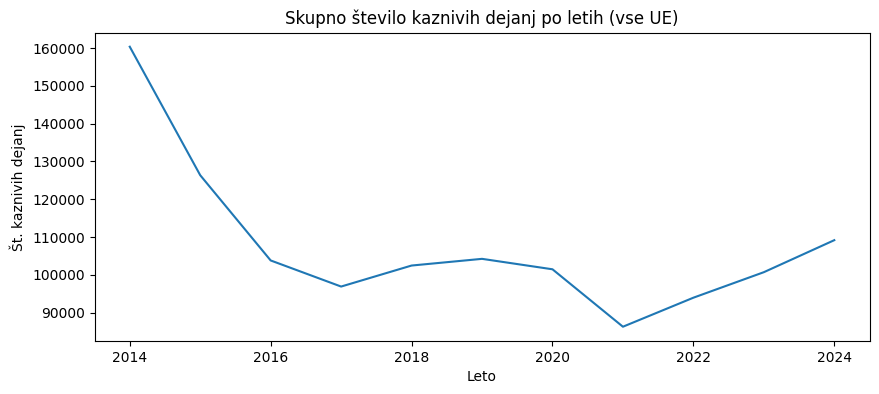

In [19]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df_master, x="leto", y="st_kaznivih_dejanj",
             estimator="sum", errorbar=None)
plt.title("Skupno število kaznivih dejanj po letih (vse UE)")
plt.xlabel("Leto"); plt.ylabel("Št. kaznivih dejanj")
plt.show()

 Po padcu med 2014–2017 sledi nihanje in ponoven dvig po 2021; trend ni strogo monotoni, zato je smiselno modelirati časovni vpliv. Razlog za upad leta 2020 in 2021 poznamo, in sicer je to pandemija covid-19. Ker je 2021 očiten outlier ga bomo iz nadaljne analize izvzeli.

## 3. 2. Top 10 UE po kaznivih dejanjih na 1000 prebivalcev (2024)

Da identificiramo najbolj izpostavljene UE na prebivalca

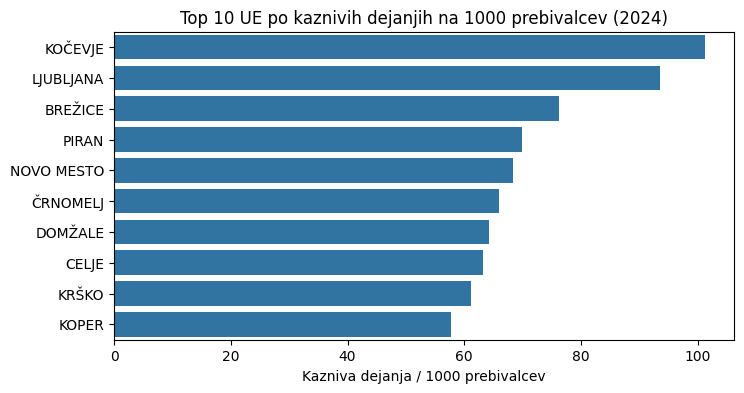

In [20]:
zadnje_leto = df_master["leto"].max()


top_rate = (df_master[df_master.leto == zadnje_leto]
            .sort_values("kriminaliteta_na_1000_preb", ascending=False)
            .head(10))

plt.figure(figsize=(8,4))
sns.barplot(data=top_rate, y="Upravna_enota", x="kriminaliteta_na_1000_preb")


plt.title(f"Top 10 UE po kaznivih dejanjih na 1000 prebivalcev ({zadnje_leto})")
plt.xlabel("Kazniva dejanja / 1000 prebivalcev")
plt.ylabel("")
plt.show()

Nekaj UE močno izstopa (npr. Kočevje, Ljubljana) in je višje od ostalih; problem ni enakomerno porazdeljen.

## 3. 3. Tri upravne enote z največ in tri upravne neote z najmanj kaznivih dejanj na 1000 prebivalcev

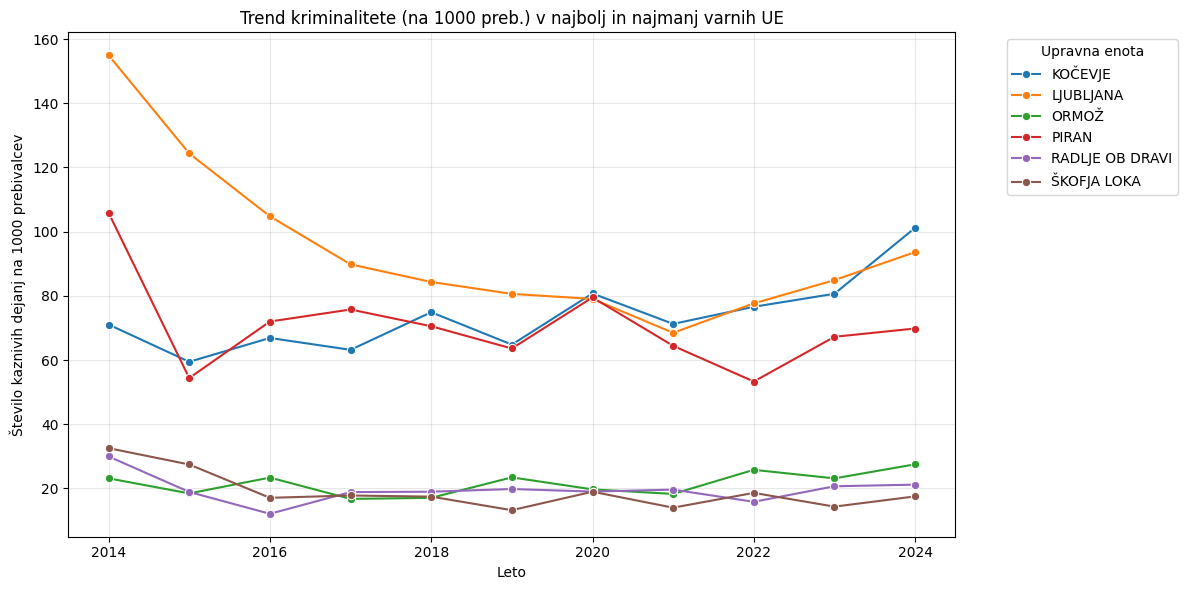

In [21]:
povprecje_kriminalitete = df_master.groupby('Upravna_enota')['kriminaliteta_na_1000_preb'].mean().sort_values()

najbolj_varne = povprecje_kriminalitete.head(3).index.tolist()
najbolj_nevarne = povprecje_kriminalitete.tail(3).index.tolist()
izbrane_ue = najbolj_varne + najbolj_nevarne

df_plot = df_master[df_master['Upravna_enota'].isin(izbrane_ue)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='leto', y='kriminaliteta_na_1000_preb', hue='Upravna_enota', marker='o')

plt.title('Trend kriminalitete (na 1000 preb.) v najbolj in najmanj varnih UE')
plt.ylabel('Število kaznivih dejanj na 1000 prebivalcev')
plt.xlabel('Leto')
plt.legend(title='Upravna enota', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Visoko tvegane UE (Ljubljana, Kočevje, Piran) so po letu 2020 spet v porastu, Kočevje 2024 celo preseže Ljubljano (~101/1000 preb.). Nizko tvegane UE (Ormož, Radlje, Škofja Loka) ostajajo stabilno nizke (12–30/1000 preb.) z le manjšimi nihanji.

## 3. 4. Upravne enote z največjim porastom kriminalitete

TOP 5 UE z največjim trendom rasti kriminalitete (11 let):


,Upravna_enota,Trend_naklon,Skupna_sprememba
1,BREŽICE,2.897181,22.873136
15,KOČEVJE,2.605258,20.345788
30,NOVO MESTO,1.451390,13.951838
26,METLIKA,0.963671,11.119367
31,ORMOŽ,0.486969,3.823601



TOP 5 UE, kjer je varnost najbolj narasla (trend pada):


,Upravna_enota,Trend_naklon,Skupna_sprememba
54,ŠENTJUR PRI CELJU,-2.979226,-24.164068
6,GORNJA RADGONA,-3.579495,-17.048422
51,VRHNIKA,-5.133328,-41.138988
22,LJUBLJANA,-5.398095,-42.638516
11,IZOLA,-6.211980,-50.654162


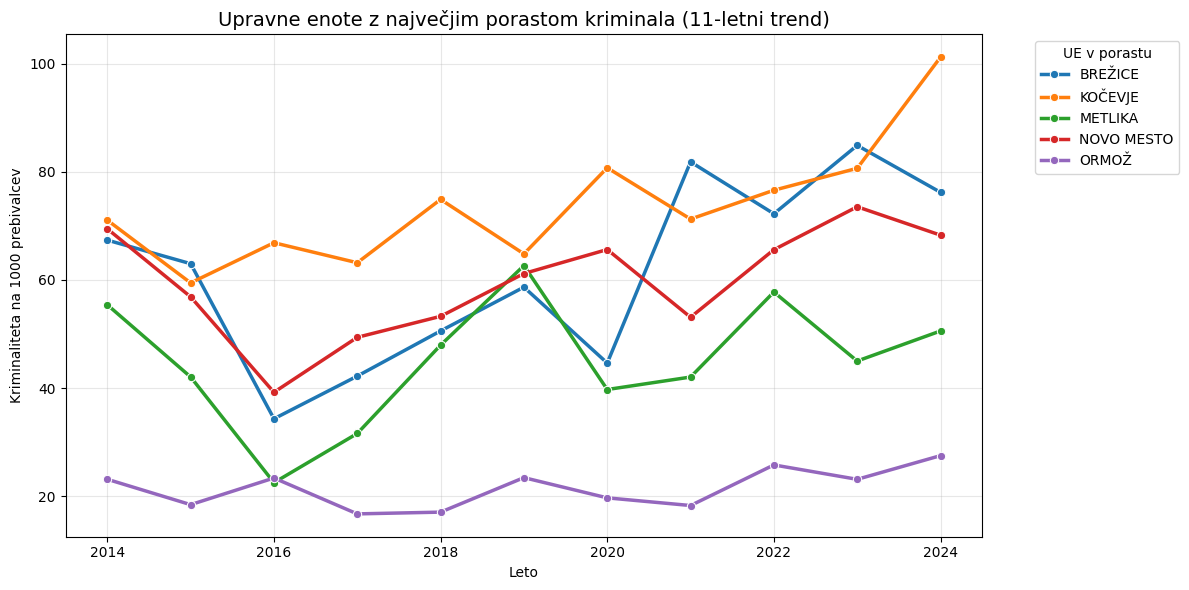

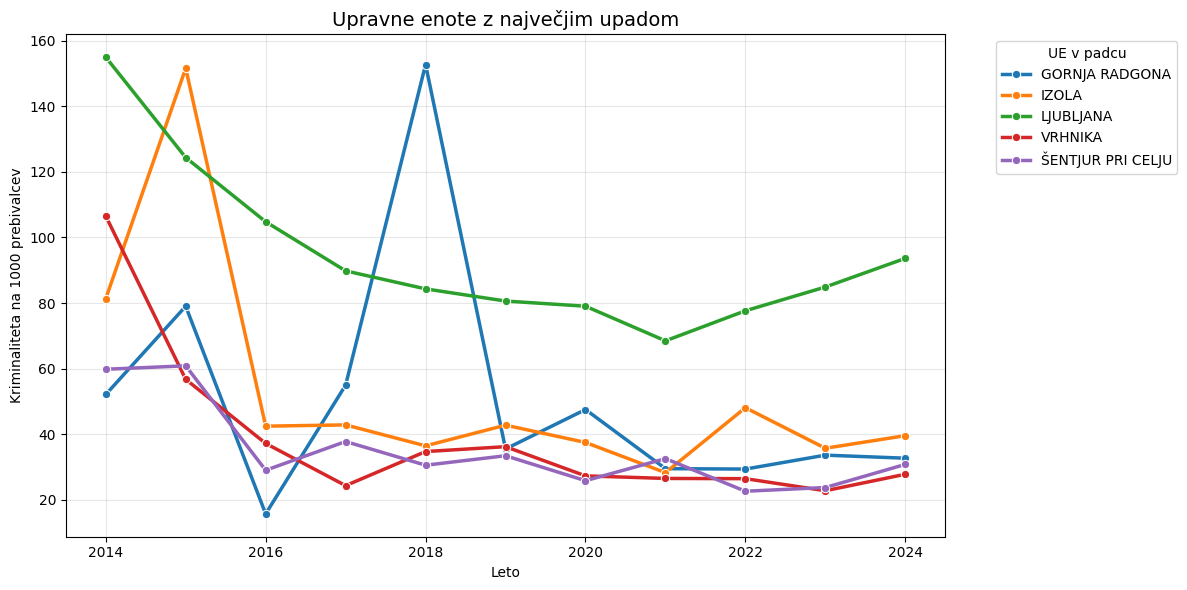

In [22]:
trend_rezultati = []


for ue in df_master['Upravna_enota'].unique():
    df_ue = df_master[df_master['Upravna_enota'] == ue]
    if len(df_ue) > 1:
        # Linregress vrne 'slope' (naklon).
        slope, intercept, r_value, p_value, std_err = linregress(df_ue['leto'], df_ue['kriminaliteta_na_1000_preb'])
        start_avg = df_ue.head(3)['kriminaliteta_na_1000_preb'].mean()
        end_avg = df_ue.tail(3)['kriminaliteta_na_1000_preb'].mean()
        diff = end_avg - start_avg

        trend_rezultati.append({
            'Upravna_enota': ue,
            'Trend_naklon': slope,
            'Skupna_sprememba': diff
        })

df_trend = pd.DataFrame(trend_rezultati).sort_values(by='Trend_naklon', ascending=False)

print("TOP 5 UE z največjim trendom rasti kriminalitete (11 let):")
display(df_trend.head(5))

print("\nTOP 5 UE, kjer je varnost najbolj narasla (trend pada):")
display(df_trend.tail(5))


najslabse_ue = df_trend.head(5)['Upravna_enota'].tolist()
df_plot_trend = df_master[df_master['Upravna_enota'].isin(najslabse_ue)]

najboljse_ue = df_trend.tail(5)['Upravna_enota'].tolist()
df_plot_trend2 = df_master[df_master['Upravna_enota'].isin(najboljse_ue)]


plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_plot_trend,
    x='leto',
    y='kriminaliteta_na_1000_preb',
    hue='Upravna_enota',
    marker='o',
    linewidth=2.5
)

plt.title('Upravne enote z največjim porastom kriminala (11-letni trend)', fontsize=14)
plt.ylabel('Kriminaliteta na 1000 prebivalcev')
plt.xlabel('Leto')
plt.grid(True, alpha=0.3)
plt.legend(title='UE v porastu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_plot_trend2,
    x='leto',
    y='kriminaliteta_na_1000_preb',
    hue='Upravna_enota',
    marker='o',
    linewidth=2.5
)

plt.title('Upravne enote z največjim upadom', fontsize=14)
plt.ylabel('Kriminaliteta na 1000 prebivalcev')
plt.xlabel('Leto')
plt.grid(True, alpha=0.3)
plt.legend(title='UE v padcu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Vidni so največji relativni upadi: Ljubljana dolgoročno pade iz ~155 (2014) na ~68 (2021), a po 2021 spet zleze proti ~94; Gornja Radgona in Izola imata kratke skoke (2015/2018), vendar na dolgi rok padeta na ~30–40 kaznivih dejanj na 1000 prebivalcev. Vrhnika in Šentjur pri Celju se od 2014 stabilno spuščata iz 60–100 na ~23–33, z le manjšimi nihanji v zadnjih letih.

## 3. 5. Prikaz korelacij s kriminaliteto na 1000 prebivalcev

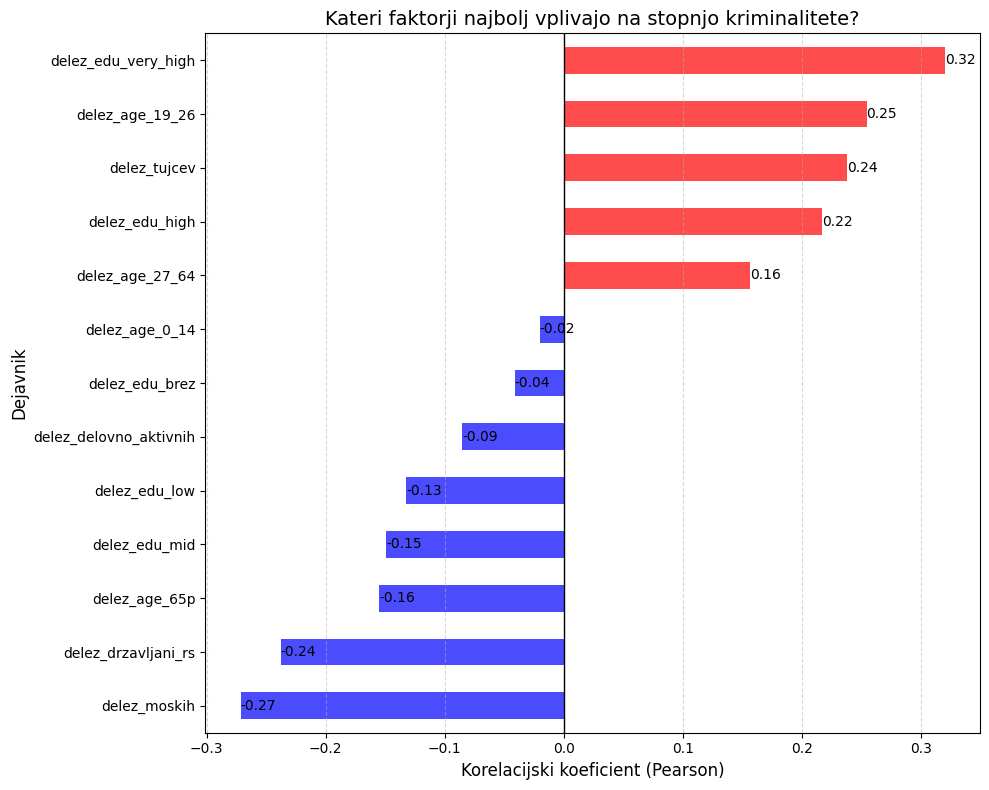

In [23]:
features_to_analyze = [
    'delez_moskih',
    'delez_tujcev',
    'delez_delovno_aktivnih',
    'delez_drzavljani_rs',
    'delez_edu_low',
    'delez_edu_mid',
    'delez_edu_high',
    'delez_edu_brez',
    'delez_edu_very_high',
    'delez_age_0_14',
    'delez_age_19_26',
    'delez_age_27_64',
    'delez_age_65p'
]

correlations = df_master[features_to_analyze + ['kriminaliteta_na_1000_preb']].corr()['kriminaliteta_na_1000_preb']
correlations = correlations.drop('kriminaliteta_na_1000_preb')
correlations = correlations.sort_values()

colors = ['red' if x > 0 else 'blue' for x in correlations]

plt.figure(figsize=(10, 8))

ax = correlations.plot(kind='barh', color=colors, alpha=0.7)

plt.title('Kateri faktorji najbolj vplivajo na stopnjo kriminalitete?', fontsize=14)
plt.xlabel('Korelacijski koeficient (Pearson)', fontsize=12)
plt.ylabel('Dejavnik', fontsize=12)
plt.axvline(0, color='black', linewidth=1) # Črta na sredini
plt.grid(axis='x', linestyle='--', alpha=0.5)

for index, value in enumerate(correlations):
    plt.text(value, index, f'{value:.2f}', va='center')

plt.tight_layout()
plt.show()

Najmočnejše pozitivne povezave s kriminaliteto imajo višji deleži najvišje izobraženih (0,32), starosti 19–26 (0,25) in tujcev (0,24), a vse korelacije ostajajo zmerne. Negativno izstopajo višji deleži moških (-0,27), državljanov RS (-0,24) ter starejših 65+ in srednje/nižjih izobraženih, kar kaže, da linearne zveze niso močne in jih je treba potrditi z modeli.

# 4. GRUČENJE


Za smiselno gručenje upravnih enot ne zadostuje linearno rangiranje po “varnosti”, temveč moramo hkrati upoštevati več razsežnosti, ki opisujejo njihov socioekonomski in urbani profil.

Kot osnovo vzamemo štiri ključne dimenzije: (1) varnost – kriminaliteta_na_1000_preb, (2) demografija – delež_tujcev, (3) ekonomija – delež_delovno_aktivnih, (4) urbanizacija – Prebivalstvo (velikost/stopnja urbanosti).

 K‑means na standardiziranih vrednostih nato sam prepozna naravne skupine, npr.

(A) “varno podeželje” z malo prebivalcev, malo tujcev in nizko kriminaliteto;

(B) “urbana središča” z več prebivalci in tujci, višjo zaposlenostjo ter praviloma višjo kriminaliteto;

(C) “problematična območja” z nižjo zaposlenostjo, a nesorazmerno višjo kriminaliteto. Tak pristop omogoča, da gruče odražajo dejanske strukturne razlike med območji, ne zgolj enodimenzionalne razlike v stopnji kriminalitete.

## 4. 1. Gručenje za vsa leta

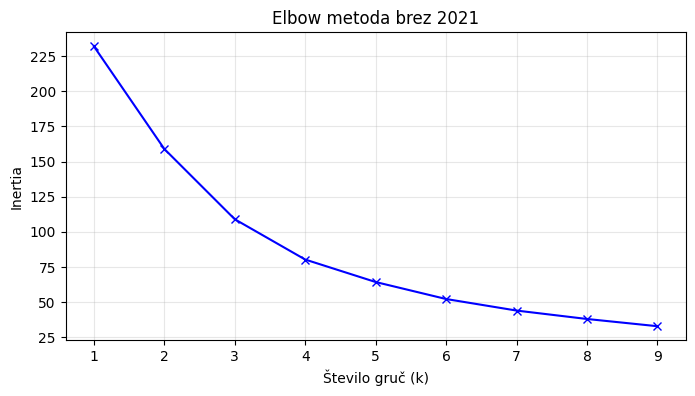

In [24]:
df_no2021 = df_master[df_master["leto"] != 2021].copy()

df_clustering = df_no2021.groupby("Upravna_enota")[[
    "kriminaliteta_na_1000_preb",
    "delez_tujcev",
    "delez_delovno_aktivnih",
    "Prebivalstvo"
]].mean()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering)


inertia = []
for i in range(1, 10):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1, 10), inertia, "bx-")
plt.xlabel("Število gruč (k)")
plt.ylabel("Inertia")
plt.title("Elbow metoda brez 2021")
plt.grid(True, alpha=0.3)
plt.show()

Metoda komolca nam pokaže, da je res najbjboljše, da uporabljamo 3 gruče

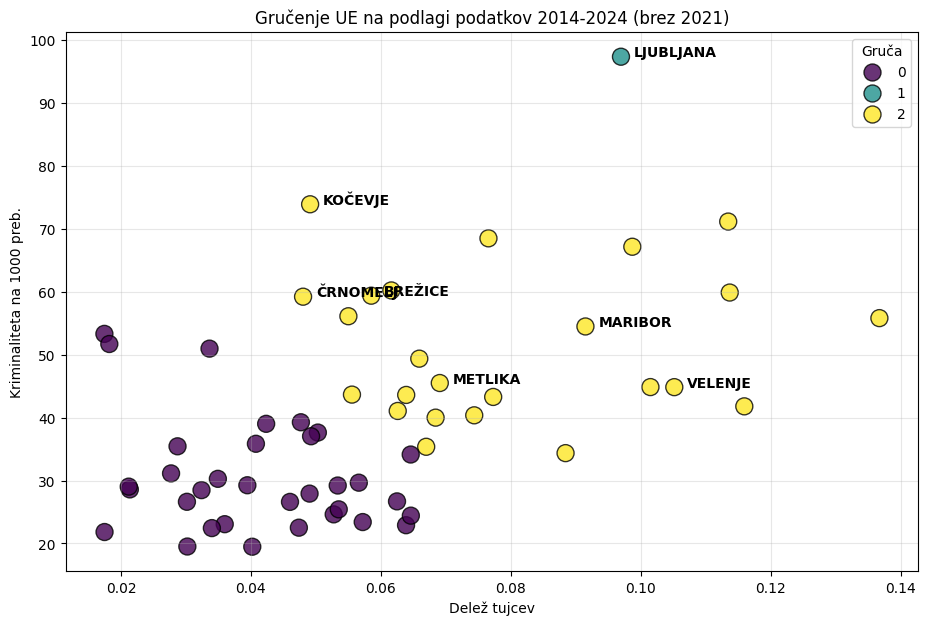

--- PROFILI GRUČ) ---


,kriminaliteta_na_1000_preb,delez_tujcev,delez_delovno_aktivnih,Prebivalstvo
Gruca,,,,
0,30.536451,0.041362,0.390850,23265.187879
2,51.428365,0.079921,0.413484,39733.866667
1,97.391752,0.096959,0.421721,365694.100000


In [25]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_clustering['Gruca'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_clustering,
    x='delez_tujcev',
    y='kriminaliteta_na_1000_preb',
    hue='Gruca',
    palette='viridis',
    s=150,
    edgecolor='black',
    alpha=0.8
)


kljucne_ue = ['LJUBLJANA', 'KOČEVJE', 'MARIBOR', 'METLIKA', 'VELENJE', 'BREŽICE', 'ČRNOMELJ']

for ue in kljucne_ue:
    if ue in df_clustering.index:
        plt.text(
            df_clustering.loc[ue, 'delez_tujcev'] + 0.002,
            df_clustering.loc[ue, 'kriminaliteta_na_1000_preb'],
            ue,
            fontsize=10,
            fontweight='bold',
            color='black'
        )

plt.title('Gručenje UE na podlagi podatkov 2014-2024 (brez 2021)')
plt.xlabel('Delež tujcev')
plt.ylabel('Kriminaliteta na 1000 preb.')
plt.grid(True, alpha=0.3)
plt.legend(title='Gruča')
plt.show()

print("--- PROFILI GRUČ) ---")
recent_profile = df_clustering.groupby('Gruca').mean().sort_values('kriminaliteta_na_1000_preb')
display(recent_profile)



Gručа 1 (turkizna, zgoraj desno): Ljubljana – samostojna kategorija z izrazito višjim deležem tujcev in najvišjo stopnjo kriminalitete (90+/1.000 preb.), kar odraža edinstven status metropole v slovenskem prostoru.

Gručа 2 (rumena, desna stran): urbana/industrijska središča – Maribor, Celje, Koper, Kranj, Brežice ipd. imajo višje deleže tujcev in povišano kriminaliteto. Kočevje izstopa kot anomalija: glede na relativno nižji delež tujcev ima nesorazmerno višjo kriminaliteto. (Lahko predvidevamo zakaj)

Gručа 0 (vijolična, levo spodaj): varna Slovenija – večina manjših UE z nizkimi deleži tujcev in nizko kriminaliteto; gre za stabilne, manj urbanizirane okolja.

## 4. 2. Gručenje pre-kovid podatkov

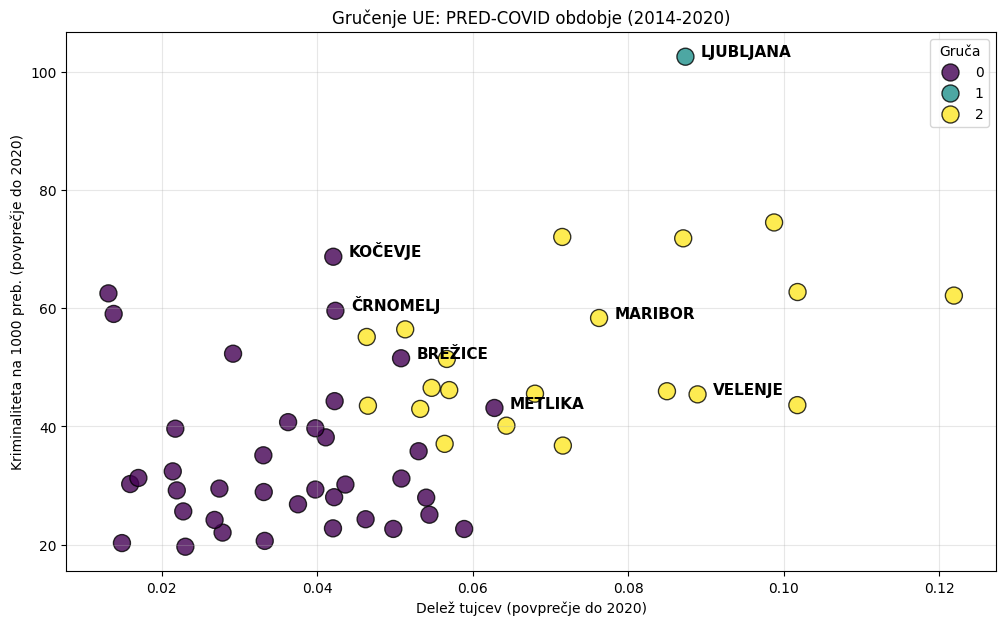

In [26]:
df_pre = df_master[df_master['leto'] < 2021].copy()

df_clustering_pre = df_pre.groupby('Upravna_enota')[[
    'kriminaliteta_na_1000_preb',
    'delez_tujcev',
    'delez_delovno_aktivnih',
    'Prebivalstvo'
]].mean()

scaler_pre = StandardScaler()
X_pre_scaled = scaler_pre.fit_transform(df_clustering_pre)

kmeans_pre = KMeans(n_clusters=k, random_state=42, n_init=10)
df_clustering_pre['Gruca'] = kmeans_pre.fit_predict(X_pre_scaled)


plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_clustering_pre,
    x='delez_tujcev',
    y='kriminaliteta_na_1000_preb',
    hue='Gruca',
    palette='viridis',
    s=150,
    edgecolor='black',
    alpha=0.8
)

kljucna_mesta = ['LJUBLJANA', 'KOČEVJE', 'MARIBOR', 'METLIKA', 'VELENJE', 'BREŽICE', 'ČRNOMELJ']
for ime in kljucna_mesta:
    if ime in df_clustering_pre.index:
        plt.text(
            df_clustering_pre.loc[ime, 'delez_tujcev'] + 0.002,
            df_clustering_pre.loc[ime, 'kriminaliteta_na_1000_preb'],
            ime,
            fontsize=11,
            fontweight='bold'
        )

plt.title('Gručenje UE: PRED-COVID obdobje (2014-2020)')
plt.xlabel('Delež tujcev (povprečje do 2020)')
plt.ylabel('Kriminaliteta na 1000 preb. (povprečje do 2020)')
plt.grid(True, alpha=0.3)
plt.legend(title='Gruča')
plt.show()


Copilot said: Pred covidom (2014–2020) je Ljubljana samostojno v
Pred covidom (2014–2020) je Ljubljana samostojno v najvišji gruči (Gruca 2): ima daleč najvišjo kriminaliteto in največji delež tujcev. Rumena gruča združuje urbana/povišana območja (npr. Koper, Maribor), z večjim deležem tujcev in srednje–visoko kriminaliteto. Vijolična gruča predstavlja večino UE z nizko kriminaliteto in nizkim deležem tujcev; Kočevje je tu izstopajoča vijolična točka z nadpovprečno kriminaliteto glede na svoj delež tujcev.

## 4. 3. Gručenje po letu 2021 (Po kovidu)

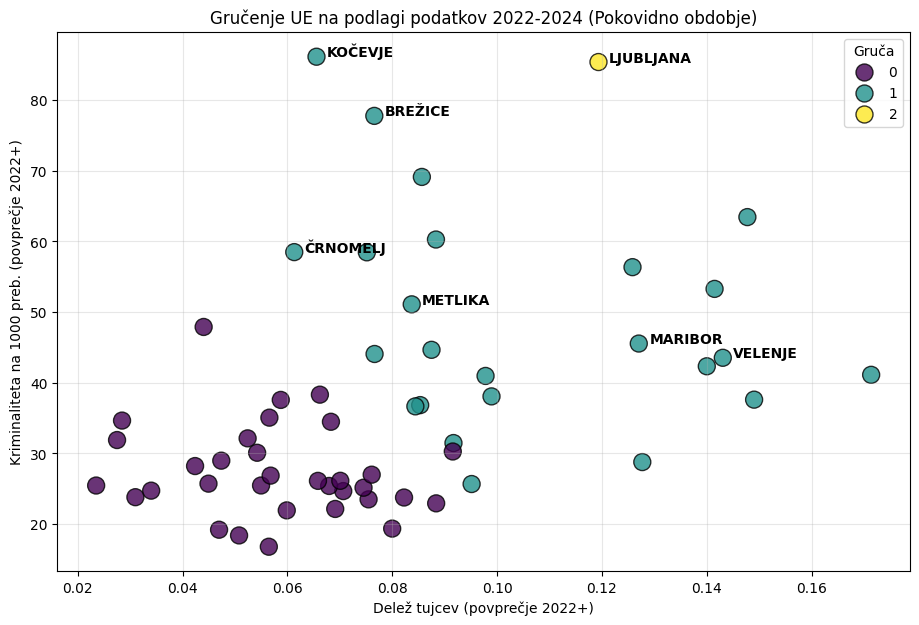

--- PROFILI GRUČ (2022-2024) ---


,kriminaliteta_na_1000_preb,delez_tujcev,delez_delovno_aktivnih,Prebivalstvo
Gruca,,,,
0,27.406824,0.058087,0.410101,23394.828283
1,48.827043,0.105277,0.432769,40555.750000
2,85.378097,0.119332,0.441747,373297.000000


In [27]:
df_recent = df_master[df_master['leto'] >= 2022].copy()

df_clustering_recent = df_recent.groupby('Upravna_enota')[[
    'kriminaliteta_na_1000_preb',
    'delez_tujcev',
    'delez_delovno_aktivnih',
    'Prebivalstvo'
]].mean()

scaler_recent = StandardScaler()
X_recent_scaled = scaler_recent.fit_transform(df_clustering_recent)

kmeans_recent = KMeans(n_clusters=k, random_state=42, n_init=10)
df_clustering_recent['Gruca'] = kmeans_recent.fit_predict(X_recent_scaled)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_clustering_recent,
    x='delez_tujcev',
    y='kriminaliteta_na_1000_preb',
    hue='Gruca',
    palette='viridis',
    s=150,
    edgecolor='black',
    alpha=0.8
)

kljucne_ue = ['LJUBLJANA', 'KOČEVJE', 'MARIBOR', 'METLIKA', 'VELENJE', 'BREŽICE', 'ČRNOMELJ']

for ue in kljucne_ue:
    if ue in df_clustering_recent.index:
        plt.text(
            df_clustering_recent.loc[ue, 'delez_tujcev'] + 0.002,
            df_clustering_recent.loc[ue, 'kriminaliteta_na_1000_preb'],
            ue,
            fontsize=10,
            fontweight='bold',
            color='black'
        )

plt.title('Gručenje UE na podlagi podatkov 2022-2024 (Pokovidno obdobje)')
plt.xlabel('Delež tujcev (povprečje 2022+)')
plt.ylabel('Kriminaliteta na 1000 preb. (povprečje 2022+)')
plt.grid(True, alpha=0.3)
plt.legend(title='Gruča')
plt.show()

print("--- PROFILI GRUČ (2022-2024) ---")
recent_profile = df_clustering_recent.groupby('Gruca').mean().sort_values('kriminaliteta_na_1000_preb')
display(recent_profile)



Na pokovidnem grafu (2022–2024) izstopa Kočevje z najvišjo kriminaliteto med “turkiznimi” (gr. 1), medtem ko Ljubljana ostaja samostojno v najvišji gruči (gr. 2) zaradi kombinacije visokega deleža tujcev in kriminalitete. Brežice se prav tako pomaknejo navzgor med bolj tveganimi, medtem ko večina ostalih UE ostaja v varnejši, vijolični gruči z nizkimi vrednostmi obeh kazalnikov.

## 4. 4. Analiza razlik

In [28]:
features = ["kriminaliteta_na_1000_preb", "delez_tujcev", "delez_delovno_aktivnih", "Prebivalstvo"]
dfs = {
    "ALL": df_clustering.copy(),
    "PRE": df_clustering_pre.copy(),
    "POST": df_clustering_recent.copy(),
}

def prepare(df):
    if df.index.name == "Upravna_enota":
        df = df.reset_index()
    elif "Upravna_enota" not in df.columns:
        df = df.reset_index().rename(columns={"index": "Upravna_enota"})
    else:
        df = df.reset_index(drop=True)
    return df

def remap_by_safety(df, cluster_col="Gruca"):
    # sort clusters by mean kriminaliteta (ascending) -> 0=varna, 1=srednja, 2=visoka
    order = df.groupby(cluster_col)["kriminaliteta_na_1000_preb"].mean().sort_values().index
    mapping = {old: new for new, old in enumerate(order)}
    df = df.copy()
    df[cluster_col + "_std"] = df[cluster_col].map(mapping)
    return df

profiles, z_profiles, importances = {}, {}, {}

# Remap in place
for tag, d in dfs.items():
    d = prepare(d)
    d = remap_by_safety(d, "Gruca")
    dfs[tag] = d
    ccol = "Gruca_std"

    # profili
    profiles[tag] = d.groupby(ccol)[features].agg(["mean", "median"])

    # z-score profili
    scaler = StandardScaler()
    Z = pd.DataFrame(scaler.fit_transform(d[features]), columns=features, index=d.index)
    z_profiles[tag] = Z.join(d[ccol]).groupby(ccol).mean()

    # RF importances
    X = d[features].fillna(d[features].median())
    y = d[ccol]
    rf = RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced")
    rf.fit(X, y)
    importances[tag] = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

# Prehodi PRE -> POST na standardiziranih etiketah
pre_df = dfs["PRE"]
post_df = dfs["POST"]

trans = pre_df[["Upravna_enota", "Gruca_std"]].merge(
    post_df[["Upravna_enota", "Gruca_std"]],
    on="Upravna_enota", how="inner", suffixes=("_pre", "_post")
)
trans["delta"] = trans["Gruca_std_post"] - trans["Gruca_std_pre"]
crosstab = pd.crosstab(trans["Gruca_std_pre"], trans["Gruca_std_post"])
moves = trans[trans["delta"] != 0].copy()
moves["Tip"] = np.where(moves["delta"] > 0, "POSLABŠANJE", "IZBOLJŠANJE")


In [29]:
print("=== Profili (mean/median) po gručah ===")
for tag, prof in profiles.items():
    print(f"\n[{tag}]"); display(prof)

=== Profili (mean/median) po gručah ===

[ALL]


kriminaliteta_na_1000_preb            delez_tujcev            \
                                mean     median         mean    median   
Gruca_std                                                                
0                          30.536451  28.599645     0.041362  0.040773   
1                          51.428365  47.450702     0.079921  0.071724   
2                          97.391752  97.391752     0.096959  0.096959   

          delez_delovno_aktivnih             Prebivalstvo            
                            mean    median           mean    median  
Gruca_std                                                            
0                       0.390850  0.400084   23265.187879   18270.7  
1                       0.413484  0.413968   39733.866667   27106.0  
2                       0.421721  0.421721  365694.100000  365694.1


[PRE]


kriminaliteta_na_1000_preb             delez_tujcev            \
                                mean      median         mean    median   
Gruca_std                                                                 
0                          34.456194   30.165905     0.035850  0.037537   
1                          51.906139   46.336511     0.072963  0.069773   
2                         102.540462  102.540462     0.087370  0.087370   

          delez_delovno_aktivnih             Prebivalstvo                 
                            mean    median           mean         median  
Gruca_std                                                                 
0                       0.381741  0.386767   22528.733591   18199.857143  
1                       0.411331  0.413749   43875.685714   33206.857143  
2                       0.413139  0.413139  362435.714286  362435.714286


[POST]


kriminaliteta_na_1000_preb            delez_tujcev            \
                                mean     median         mean    median   
Gruca_std                                                                
0                          27.406824  25.732787     0.058087  0.056781   
1                          48.827043  44.371035     0.105277  0.093397   
2                          85.378097  85.378097     0.119332  0.119332   

          delez_delovno_aktivnih             Prebivalstvo            
                            mean    median           mean    median  
Gruca_std                                                            
0                       0.410101  0.421361   23394.828283   17949.0  
1                       0.432769  0.434211   40555.750000   27708.5  
2                       0.441747  0.441747  373297.000000  373297.0

V vseh obdobjih se gruča 1 jasno loči kot “Ljubljana”: najvišja kriminaliteta (~ 95–103 na 1.000 preb.), največ tujcev (~ 0,09-0,12) in velikost mesta (~ 360–373k). Gruča 0 ostaja nizkotvegana (kriminaliteta ~ 27–35; manj tujcev; manjša populacija), gruča 2 pa je vmesna urbana skupina s srednjo kriminaliteto (~ 49–52) ter višjim deležem tujcev in večjo populacijo kot gruča 0.

In [30]:
print("\n=== Z-score profili (odklon od povprečja v obdobju) ===")
for tag, zprof in z_profiles.items():
    print(f"\n[{tag}]"); display(zprof)


=== Z-score profili (odklon od povprečja v obdobju) ===

[ALL]


,kriminaliteta_na_1000_preb,delez_tujcev,delez_delovno_aktivnih,Prebivalstvo
Gruca_std,,,,
0,-0.610777,-0.625451,-0.347883,-0.257658
1,0.691613,0.800394,0.447624,0.075971
2,3.556944,1.430422,0.737146,6.679413



[PRE]


,kriminaliteta_na_1000_preb,delez_tujcev,delez_delovno_aktivnih,Prebivalstvo
Gruca_std,,,,
0,-0.429273,-0.558154,-0.376897,-0.270277
1,0.612403,0.955437,0.661037,0.166103
2,3.635024,1.542978,0.724454,6.678195



[POST]


,kriminaliteta_na_1000_preb,delez_tujcev,delez_delovno_aktivnih,Prebivalstvo
Gruca_std,,,,
0,-0.606424,-0.615609,-0.341833,-0.260586
1,0.710587,0.795789,0.438851,0.079900
2,2.957909,1.216142,0.748044,6.681749


Gruča 1 je v vseh obdobjih močno pozitivno odstopala (visoka kriminaliteta, več tujcev, nadpovprečna zaposlenost in izjemno velika populacija – tipično Ljubljana). Gruča 0 ima dosledno negativne z‑score (nizka kriminaliteta, malo tujcev, manjša populacija), gruča 2 pa zmerno pozitivne vrednosti kot vmesna urbana skupina.

In [31]:
print("\n=== Feature importances (RF) za ločevanje gruč ===")
for tag, imp in importances.items():
    print(f"\n[{tag}]"); display(imp)


=== Feature importances (RF) za ločevanje gruč ===

[ALL]


,0
kriminaliteta_na_1000_preb,0.493660
delez_tujcev,0.256108
Prebivalstvo,0.179916
delez_delovno_aktivnih,0.070316



[PRE]


,0
kriminaliteta_na_1000_preb,0.368166
delez_tujcev,0.331281
Prebivalstvo,0.197611
delez_delovno_aktivnih,0.102942



[POST]


,0
kriminaliteta_na_1000_preb,0.447205
delez_tujcev,0.280377
Prebivalstvo,0.201939
delez_delovno_aktivnih,0.070480


RandomForest pokaže, da je pri ločevanju gruč najmočnejša spremenljivka kriminaliteta_na_1000_preb (≈37–49% uteži). Sledi delež_tujcev (≈25–33%) in Prebivalstvo (≈18–20%), medtem ko delez_delovno_aktivnih dosledno prispeva najmanj (≈7–10%)

In [32]:

print(f"Št. premikov: {len(moves)}")
kr_pre = pre_df[["Upravna_enota", "kriminaliteta_na_1000_preb"]].rename(
    columns={"kriminaliteta_na_1000_preb": "krim_pre"}
)
kr_post = post_df[["Upravna_enota", "kriminaliteta_na_1000_preb"]].rename(
    columns={"kriminaliteta_na_1000_preb": "krim_post"}
)

moves_kr = moves.merge(kr_pre, on="Upravna_enota", how="left").merge(
    kr_post, on="Upravna_enota", how="left"
)
moves_kr["krim_diff"] = moves_kr["krim_post"] - moves_kr["krim_pre"]

display(
    moves_kr[
        ["Upravna_enota", "Gruca_std_pre", "Gruca_std_post", "Tip", "krim_pre", "krim_post", "krim_diff"]
    ].sort_values("krim_post", ascending=False)
)


Št. premikov: 4


,Upravna_enota,Gruca_std_pre,Gruca_std_post,Tip,krim_pre,krim_post,krim_diff
1,KOČEVJE,0,1,POSLABŠANJE,68.704177,86.130558,17.426380
0,BREŽICE,0,1,POSLABŠANJE,51.529900,77.760953,26.231053
3,ČRNOMELJ,0,1,POSLABŠANJE,59.560208,58.488588,-1.071621
2,METLIKA,0,1,POSLABŠANJE,43.120143,51.100414,7.980270


Dobili smo premike v 4 upravnih enotah
Kočevje, Brežice, Metlika, Črnomelj (0→1).
Iz manjših bolj varnih naselj v manj varne. Smiselno lahko sklepamo zakaj se je premik zgodil, saj je pri 3 od 4 upravnih enot precej povečana kriminaliteta na 1000 prebivalcev.

# 5. KLASIFIKACIJA

## 5. 1. KLASIFIKACIJA V TRI SKUPINE

Št. trening vrstic: 522, št. test vrstic (2024): 58
Accuracy (2024): 0.6724137931034483
              precision    recall  f1-score   support

       Varna       0.74      0.74      0.74        19
     Srednja       0.50      0.58      0.54        19
     Nevarna       0.82      0.70      0.76        20

    accuracy                           0.67        58
   macro avg       0.69      0.67      0.68        58
weighted avg       0.69      0.67      0.68        58



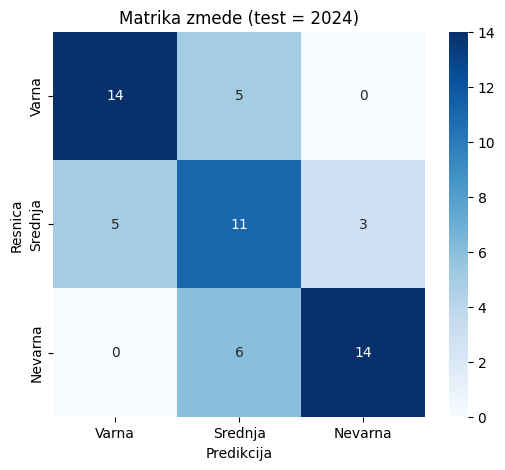

/tmp/ipython-input-2177524266.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='magma')


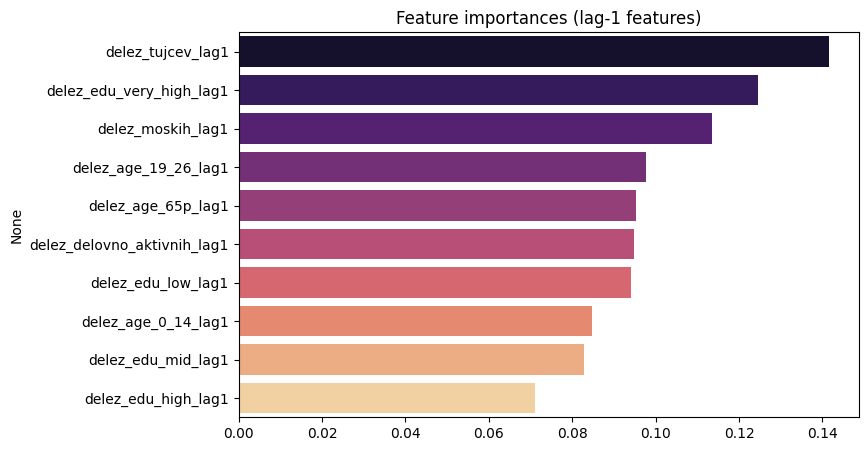

In [53]:
# Priprava: napoved za leto 2024 z lag=1 (uporabimo lastno leto-1 kot značilke)
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1) nastavitev značilk (prilagodi po potrebi)
features = [
    'delez_tujcev', 'delez_delovno_aktivnih', 'delez_moskih',
    'delez_edu_low','delez_edu_mid','delez_edu_high','delez_edu_very_high',
    'delez_age_19_26','delez_age_65p','delez_age_0_14'
]

# 2) naredimo "lag-1" značilke: za target v letu t uporabimo vrednosti iz leta t-1
#    (kopija letnika z leto+1, da se dajo mergeat kot prejšnje leto)
lag_df = df_master[['Upravna_enota', 'leto'] + features].copy()
lag_df = lag_df.rename(columns={c: f"{c}_lag1" for c in features})
lag_df['leto'] = lag_df['leto'] + 1  # shift: vrednosti iz leta y se uporabijo kot lag za leto y+1

# merge: pridobimo za vsak row v df_master značilke iz leta-1 (če obstajajo)
data = df_master.merge(lag_df, on=['Upravna_enota', 'leto'], how='left')

# 3) target: uporabimo kriminaliteto v letu t (lahko ustvarimo razrede glede na kvantile iz treninga)
#    Najprej izločimo vrstice brez lag značilk (npr. prvo leto v nizu) ali jih obdelamo posebej.
data = data.dropna(subset=[f"{features[0]}_lag1"])  # enostavno: zahtevamo vsaj eno lag značilko

# 4) ločimo trening in test (test = leto 2024)
train = data[data['leto'] <= 2023].copy()
test  = data[data['leto'] == 2024].copy()

# Če test prazen -> preveri, ali imaš podatke za 2024
print(f"Št. trening vrstic: {len(train)}, št. test vrstic (2024): {len(test)}")

# 5) definiraj tri razrede na podlagi kvantilov iz treninga (da ni leakage)
q1 = train['kriminaliteta_na_1000_preb'].quantile(0.33)
q2 = train['kriminaliteta_na_1000_preb'].quantile(0.66)

def target_from_value(v, q1=q1, q2=q2):
    if v <= q1: return 0
    elif v <= q2: return 1
    else: return 2

train['Target'] = train['kriminaliteta_na_1000_preb'].apply(target_from_value)
# za test uporabimo iste meje q1,q2 (NE izračunavaj novih kvantilov na testu)
test['Target']  = test['kriminaliteta_na_1000_preb'].apply(target_from_value)

# 6) X/y: vzemi lag značilke (_lag1)
X_train = train[[f"{c}_lag1" for c in features]].fillna(0)
y_train = train['Target']
X_test  = test[[f"{c}_lag1" for c in features]].fillna(0)
y_test  = test['Target']

# 7) treniranje modela (primer: RandomForest)
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# 8) napoved in eval na letu 2024
y_pred = rf.predict(X_test)
print("Accuracy (2024):", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Varna','Srednja','Nevarna']))

# 9) confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Varna','Srednja','Nevarna'], yticklabels=['Varna','Srednja','Nevarna'])
plt.xlabel('Predikcija'); plt.ylabel('Resnica'); plt.title('Matrika zmede (test = 2024)')
plt.show()

# 10) (opcijsko) feature importances
importances = pd.Series(rf.feature_importances_, index=[f"{c}_lag1" for c in features]).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('Feature importances (lag-1 features)')
plt.show()

Letni razpon za evaluacijo: 2015 -> 2024
Fold (test=2016): acc=0.500, f1_macro=0.488, n_train=58, n_test=58
Fold (test=2017): acc=0.603, f1_macro=0.599, n_train=116, n_test=58
Fold (test=2018): acc=0.707, f1_macro=0.710, n_train=174, n_test=58
Fold (test=2019): acc=0.741, f1_macro=0.746, n_train=232, n_test=58
Fold (test=2020): acc=0.534, f1_macro=0.545, n_train=290, n_test=58
Fold (test=2021): acc=0.621, f1_macro=0.616, n_train=348, n_test=58
Fold (test=2022): acc=0.672, f1_macro=0.654, n_train=406, n_test=58
Fold (test=2023): acc=0.690, f1_macro=0.675, n_train=464, n_test=58
Fold (test=2024): acc=0.724, f1_macro=0.723, n_train=522, n_test=58

Povprečje metrike across folds:
           n_train  n_test  accuracy  f1_macro
test_year                                     
2016            58      58  0.500000  0.488196
2017           116      58  0.603448  0.599434
2018           174      58  0.706897  0.709552
2019           232      58  0.741379  0.745805
2020           290      58  0.534

,0
delez_tujcev_lag1,0.124727
delez_edu_brez_lag1,0.111127
delez_edu_very_high_lag1,0.106637
delez_moskih_lag1,0.101906
delez_edu_low_lag1,0.097273
delez_age_65p_lag1,0.083182
delez_age_0_14_lag1,0.081638
delez_age_19_26_lag1,0.076424
delez_edu_high_lag1,0.075495
delez_delovno_aktivnih_lag1,0.074808



Akumulirana confusion matrix (seštevek po vseh test letih):


,Pred_Varna,Pred_Srednja,Pred_Nev
True_Varna,131,56,13
True_Srednja,42,98,38
True_Nev,6,31,107



Podrobno poročilo za test_year=2024:


,precision,recall,f1-score,support
Varna,0.700000,0.736842,0.717949,19.000000
Srednja,0.578947,0.578947,0.578947,19.000000
Nevarna,0.894737,0.850000,0.871795,20.000000
accuracy,0.724138,0.724138,0.724138,0.724138
macro avg,0.724561,0.721930,0.722897,58.000000
weighted avg,0.727495,0.724138,0.725464,58.000000


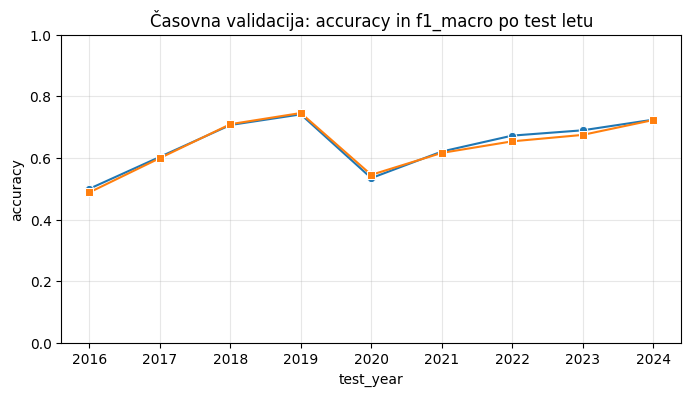

In [52]:
# 1) nastavi features (uporabi svoje)
features = [
    'delez_tujcev', 'delez_delovno_aktivnih', 'delez_moskih',
    'delez_edu_low','delez_edu_mid','delez_edu_high','delez_edu_very_high', 'delez_edu_brez',
    'delez_age_19_26','delez_age_65p','delez_age_0_14'
]

# 2) pripravi lag-1 značilke (isto kot prej)
lag_df = df_master[['Upravna_enota', 'leto'] + features].copy()
lag_df = lag_df.rename(columns={c: f"{c}_lag1" for c in features})
lag_df['leto'] = lag_df['leto'] + 1  # shift: vrednosti iz leta y so lag za y+1

data = df_master.merge(lag_df, on=['Upravna_enota', 'leto'], how='left')
# zahtevamo vsaj eno lag značilko (ali prilagodi)
data = data.dropna(subset=[f"{features[0]}_lag1"]).copy()

# 3) določimo sezname testnih let (vsi leti, kjer imamo lag)
years = sorted(data['leto'].unique())
start_test_year = min(years)  # prvi leto, za katerega imamo lag vrednosti
end_test_year = max(years)    # npr. 2024

print("Letni razpon za evaluacijo:", start_test_year, "->", end_test_year)

# 4) pripravimo strukture za zbiranje rezultatov
results = []
cm_total = np.zeros((3,3), dtype=int)  # za akumulirano matriko zmede
feat_imps = []

# 5) expanding-window time validation: za vsak test_year treniraj na leto < test_year
for test_year in range(start_test_year+0, end_test_year+1):  # prilagodi začetni offset po potrebi
    train = data[data['leto'] < test_year].copy()
    test  = data[data['leto'] == test_year].copy()
    # če ni dovolj podatkov za train ali test preskoči fold
    if train.empty or test.empty:
        continue

    # 6) target meje (kvantili) izračunamo SAMO na trainu -> brez leakage
    q1 = train['kriminaliteta_na_1000_preb'].quantile(0.33)
    q2 = train['kriminaliteta_na_1000_preb'].quantile(0.66)
    def make_target(v, q1=q1, q2=q2):
        if v <= q1: return 0
        elif v <= q2: return 1
        else: return 2

    train['Target_fold'] = train['kriminaliteta_na_1000_preb'].apply(make_target)
    test['Target_fold']  = test['kriminaliteta_na_1000_preb'].apply(make_target)

    X_train = train[[f"{c}_lag1" for c in features]].fillna(0)
    y_train = train['Target_fold']
    X_test  = test[[f"{c}_lag1" for c in features]].fillna(0)
    y_test  = test['Target_fold']

    # 7) treniraj model (isti hiperparametri kot prej)
    rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
    rf.fit(X_train, y_train)

    # 8) napoved in metrika
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro')
    cr = classification_report(y_test, y_pred, target_names=['Varna','Srednja','Nevarna'], output_dict=True)

    # shrani rezultate
    results.append({
        'test_year': test_year,
        'n_train': len(X_train),
        'n_test': len(X_test),
        'accuracy': acc,
        'f1_macro': f1m,
        'report': cr
    })

    # akumuliraj confusion matrix in feature importances
    cm = confusion_matrix(y_test, y_pred, labels=[0,1,2])
    cm_total += cm
    feat_imps.append(rf.feature_importances_)

    print(f"Fold (test={test_year}): acc={acc:.3f}, f1_macro={f1m:.3f}, n_train={len(X_train)}, n_test={len(X_test)}")

# 9) povzetek across folds
res_df = pd.DataFrame(results)
if not res_df.empty:
    print("\nPovprečje metrike across folds:")
    print(res_df[['test_year','n_train','n_test','accuracy','f1_macro']].set_index('test_year'))

    print("\nSrednja/nstd accuracy:", res_df['accuracy'].mean(), "+/-", res_df['accuracy'].std())
    print("Srednja/nstd f1_macro:", res_df['f1_macro'].mean(), "+/-", res_df['f1_macro'].std())

    # povprečna feature importance
    mean_imp = np.mean(feat_imps, axis=0)
    imp_series = pd.Series(mean_imp, index=[f"{c}_lag1" for c in features]).sort_values(ascending=False)
    print("\nPovprečna feature importance (po foldih):")
    display(imp_series)

    # akumulirana confusion matrix
    print("\nAkumulirana confusion matrix (seštevek po vseh test letih):")
    display(pd.DataFrame(cm_total, index=['True_Varna','True_Srednja','True_Nev'], columns=['Pred_Varna','Pred_Srednja','Pred_Nev']))

    # opcijsko: izpiši podrobno poročilo za zadnji fold (zadnji test_year)
    last = res_df.iloc[-1]
    print(f"\nPodrobno poročilo za test_year={int(last['test_year'])}:")
    display(pd.DataFrame(last['report']).T)
else:
    print("Ni bilo foldov za evaluacijo (premalo podatkov).")

# 10) (opcijsko) graf accuracy po letih
if not res_df.empty:
    plt.figure(figsize=(8,4))
    sns.lineplot(data=res_df, x='test_year', y='accuracy', marker='o')
    sns.lineplot(data=res_df, x='test_year', y='f1_macro', marker='s')
    plt.ylim(0,1)
    plt.title('Časovna validacija: accuracy in f1_macro po test letu')
    plt.grid(alpha=0.3)
    plt.show()

In [34]:
# --- 1. RAZDELITEV PODATKOV NA PRETEKLOST (UČENJE) IN SEDANJOST (TEST 2024) ---

# Določimo meje razredov na podlagi ZGODOVINE (do 2023)
# To je pomembno! Ne smemo gledati prihodnosti, da določimo, kaj je "varno".
df_history = df_master[df_master['leto'] < 2024].copy()
df_2024 = df_master[df_master['leto'] == 2024].copy()

q1 = df_history['kriminaliteta_na_1000_preb'].quantile(0.33)
q2 = df_history['kriminaliteta_na_1000_preb'].quantile(0.66)

print(f"Meje (na podlagi zgodovine): Varna < {q1:.1f} | Nevarna > {q2:.1f}")

# Funkcija za določanje razredov
def doloci_razred(x):
    if x <= q1: return 0      # VARNA
    elif x <= q2: return 1    # SREDNJA
    else: return 2            # NEVARNA

# Dodelimo razrede obema tabelama
df_history['Target'] = df_history['kriminaliteta_na_1000_preb'].apply(doloci_razred)
df_2024['Target'] = df_2024['kriminaliteta_na_1000_preb'].apply(doloci_razred)

# --- 2. PRIPRAVA ZNAČILK (Iste kot prej) ---
features = [
    'delez_tujcev', 'delez_delovno_aktivnih', 'delez_moskih',
    'delez_edu_low', 'delez_edu_mid', 'delez_edu_high', 'delez_edu_very_high',
    'delez_age_19_26', 'delez_age_65p', 'delez_age_0_14'
]

X_train = df_history[features].fillna(0)
y_train = df_history['Target']

X_2024 = df_2024[features].fillna(0)
y_2024 = df_2024['Target']

# --- 3. UČENJE MODELA NA ZGODOVINI ---
rf_time = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_time.fit(X_train, y_train)

# --- 4. NAPOVEDOVANJE ZA 2024 ---
y_pred_2024 = rf_time.predict(X_2024)
acc_2024 = accuracy_score(y_2024, y_pred_2024)

print(f"\nTOČNOST NAPOVEDI ZA LETO 2024: {acc_2024:.1%}")

# --- 5. ANALIZA REZULTATOV (Kje je zadel, kje zgrešil?) ---
# Ustvarimo pregledno tabelo rezultatov
rezultati = df_2024[['Upravna_enota', 'kriminaliteta_na_1000_preb']].copy()
rezultati['Dejansko_2024'] = y_2024
rezultati['Napoved_Model'] = y_pred_2024

# Mapiranje številk v besede za lepši izpis
ime_razreda = {0: '🟢 Varna', 1: '🟡 Srednja', 2: '🔴 Nevarna'}
rezultati['Dejansko_Opis'] = rezultati['Dejansko_2024'].map(ime_razreda)
rezultati['Napoved_Opis'] = rezultati['Napoved_Model'].map(ime_razreda)

# Iščemo napake (kjer se napoved razlikuje od dejanskega)
napake = rezultati[rezultati['Dejansko_2024'] != rezultati['Napoved_Model']].copy()

print(f"\nModel je pravilno napovedal {len(rezultati) - len(napake)} od {len(rezultati)} občin.")
print("\n--- ZANIMIVI KIKS-I (Kjer nas je 2024 presenetilo) ---")
# Prikaz tistih, kjer je dejansko stanje SLABŠE od napovedi (Model rekel Varno, bilo je Nevarno)
negativna_presenecenja = napake[napake['Dejansko_2024'] > napake['Napoved_Model']]
display(negativna_presenecenja[['Upravna_enota', 'kriminaliteta_na_1000_preb', 'Napoved_Opis', 'Dejansko_Opis']])

print("\n--- KLJUČNA MESTA (Preverimo naše znance) ---")
kljucna = ['LJUBLJANA', 'KOČEVJE', 'BREŽICE', 'MARIBOR', 'KOPER', 'VELENJE', 'VRHNIKA']
display(rezultati[rezultati['Upravna_enota'].isin(kljucna)][['Upravna_enota', 'Napoved_Opis', 'Dejansko_Opis']])

Meje (na podlagi zgodovine): Varna < 28.5 | Nevarna > 41.7

TOČNOST NAPOVEDI ZA LETO 2024: 69.0%

Model je pravilno napovedal 40 od 58 občin.

--- ZANIMIVI KIKS-I (Kjer nas je 2024 presenetilo) ---


,Upravna_enota,kriminaliteta_na_1000_preb,Napoved_Opis,Dejansko_Opis
596,KRANJ,52.142415,🟡 Srednja,🔴 Nevarna
600,LENDAVA,44.514307,🟡 Srednja,🔴 Nevarna
601,LITIJA,30.779185,🟢 Varna,🟡 Srednja
609,NOVA GORICA,42.637784,🟡 Srednja,🔴 Nevarna
619,RIBNICA,36.405168,🟢 Varna,🟡 Srednja
620,RUŠE,32.457284,🟢 Varna,🟡 Srednja
623,SLOVENJ GRADEC,40.120176,🟢 Varna,🟡 Srednja
625,SLOVENSKE KONJICE,33.145998,🟢 Varna,🟡 Srednja
628,TREBNJE,48.448751,🟡 Srednja,🔴 Nevarna
630,VELENJE,46.489564,🟡 Srednja,🔴 Nevarna



--- KLJUČNA MESTA (Preverimo naše znance) ---


,Upravna_enota,Napoved_Opis,Dejansko_Opis
581,BREŽICE,🔴 Nevarna,🔴 Nevarna
594,KOPER,🔴 Nevarna,🔴 Nevarna
595,KOČEVJE,🔴 Nevarna,🔴 Nevarna
602,LJUBLJANA,🔴 Nevarna,🔴 Nevarna
605,MARIBOR,🔴 Nevarna,🔴 Nevarna
630,VELENJE,🟡 Srednja,🔴 Nevarna
631,VRHNIKA,🟢 Varna,🟢 Varna


"Naš model je dosegel visoko, 69-odstotno natančnost pri napovedi varnosti za leto 2024 zgolj na podlagi preteklih demografskih trendov.

Še bolj zgovorna pa je analiza napak: Model je bil v letu 2024 sistematično preveč optimističen. V kar 12 primerih je napovedal nižjo stopnjo nevarnosti, kot se je dejansko zgodila (npr. Kranj, Velenje, Trebnje).

Zaključek: Leto 2024 predstavlja prelomnico, kjer se je varnostna situacija v številnih občinah (Trebnje, Ribnica, Kranj) poslabšala hitreje, kot bi lahko sklepali zgolj iz sprememb v prebivalstvu. To nakazuje na zunanje dejavnike ali širjenje kriminalnih žarišč izven tradicionalnih con."

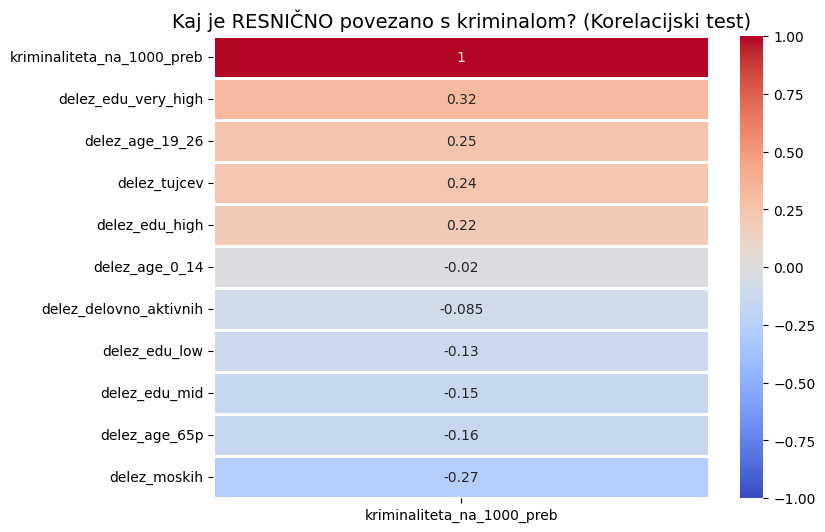

In [35]:


# Izberemo faktorje za primerjavo mitov
faktorji_za_primerjavo = [
    'kriminaliteta_na_1000_preb',
    'delez_tujcev',             # Ključni demografski faktor
    'delez_delovno_aktivnih',   # Ekonomski status
    'delez_moskih',            # Spolna struktura (včasih vpliva)
    'delez_edu_low',            # Nizka izobrazba (socialni status)
    'delez_edu_mid',
    'delez_edu_high',           # Visoka izobrazba
    'delez_edu_very_high',
    'delez_age_19_26',          # "Riskantna" skupina (mladi odrasli)
    'delez_age_65p',            # Starejše prebivalstvo (ponavadi bolj varno)
    'delez_age_0_14'                 # Urbanizacija
]

# Izračunamo korelacijo
corr_matrix = df_master[faktorji_za_primerjavo].corr()

# Fokusiramo se samo na prvi stolpec (povezava s kriminalom)
kriminal_corr = corr_matrix[['kriminaliteta_na_1000_preb']].sort_values(by='kriminaliteta_na_1000_preb', ascending=False)

# Vizualizacija
plt.figure(figsize=(8, 6))
sns.heatmap(kriminal_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=1)
plt.title('Kaj je RESNIČNO povezano s kriminalom? (Korelacijski test)', fontsize=14)
plt.show()

"Model je kot najpomembnejšo ločnico izbral delež prebivalcev z zelo visoko izobrazbo. Pregled podatkov razkriva, da ta spremenljivka ne pomeni, da izobraženci delajo kriminal, ampak deluje kot indikator urbanizacije.

Na vrhu seznama po izobrazbi so izključno večja slovenska mesta (Ljubljana, Maribor, Kranj, Koper) in njihova predmestja. Ker je kriminaliteta pojav, ki je neločljivo povezan z gostoto poselitve in mestnim življenjem, je model to spremenljivko uporabil kot najboljši filter za ločevanje 'Mestne Slovenije' (visok riziko) od 'Podeželske Slovenije' (nižji riziko)."

In [36]:
# Izberemo zadnje razpoložljivo leto (2024), da bo slika aktualna
df_check = df_master[df_master['leto'] == 2024].copy()

# Razvrstimo po deležu zelo visoke izobrazbe (padajoče)
# Če imata dve UE enak delež, odloča velikost prebivalstva
df_sorted = df_check.sort_values(
    by=['delez_edu_very_high', 'Prebivalstvo'],
    ascending=[False, False]
)[['Upravna_enota', 'delez_edu_very_high', 'kriminaliteta_na_1000_preb', 'Prebivalstvo']]

# Prikaz prvih 15 mest
print("--- TOP 15 OBČIN PO DELEŽU ZELO VISOKE IZOBRAZBE (2024) ---")
display(df_sorted.head(15))

# Prikaz zadnjih 15 mest (za kontrast)
print("\n--- OBČINE Z NAJNIŽJIM DELEŽEM ZELO VISOKE IZOBRAZBE ---")
display(df_sorted.tail(15))

--- TOP 15 OBČIN PO DELEŽU ZELO VISOKE IZOBRAZBE (2024) ---


,Upravna_enota,delez_edu_very_high,kriminaliteta_na_1000_preb,Prebivalstvo
602,LJUBLJANA,0.037464,93.617837,375719.0
631,VRHNIKA,0.021573,27.805770,26793.0
584,DOMŽALE,0.021173,64.285714,62580.0
605,MARIBOR,0.019804,48.896824,151789.0
617,RADOVLJICA,0.019503,39.373186,35481.0
613,PIRAN,0.019126,69.813720,18091.0
604,LOGATEC,0.018711,38.420562,15018.0
596,KRANJ,0.018135,52.142415,83924.0
591,IZOLA,0.017235,39.567909,16478.0
593,KAMNIK,0.016875,35.895764,36801.0



--- OBČINE Z NAJNIŽJIM DELEŽEM ZELO VISOKE IZOBRAZBE ---


,Upravna_enota,delez_edu_very_high,kriminaliteta_na_1000_preb,Prebivalstvo
619,RIBNICA,0.007995,36.405168,14009.0
625,SLOVENSKE KONJICE,0.007958,33.145998,24377.0
600,LENDAVA,0.007882,44.514307,21948.0
603,LJUTOMER,0.007408,18.957070,17144.0
597,KRŠKO,0.006979,61.230931,28515.0
621,SEVNICA,0.006896,24.620996,17546.0
585,DRAVOGRAD,0.006827,22.530724,8788.0
586,GORNJA RADGONA,0.006810,32.699049,19970.0
636,ŠMARJE PRI JELŠAH,0.006347,32.699597,33242.0
595,KOČEVJE,0.006331,101.181862,16584.0


/tmp/ipython-input-1357576491.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coeffs, x='Vpliv (Koeficient)', y='Faktor', palette=colors)


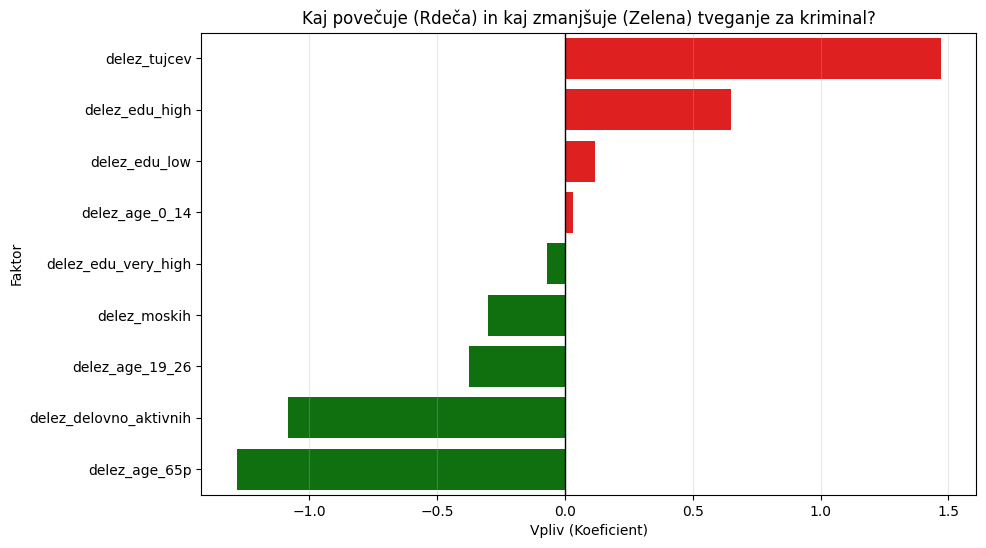

Interpretacija:
RDEČA (Desno): Več tega faktorja pomeni večjo verjetnost, da je občina NEVARNA.
ZELENA (Levo): Več tega faktorja pomeni večjo verjetnost, da je občina VARNA.


In [38]:
# --- 3. CELICA: SMER VPLIVA (Logistična regresija) ---

# Logistična regresija rabi standardizirane podatke
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Izpis koeficientov
coeffs = pd.DataFrame({
    'Faktor': features,
    'Vpliv (Koeficient)': log_reg.coef_[0]
}).sort_values(by='Vpliv (Koeficient)', ascending=False)

# Vizualizacija
plt.figure(figsize=(10, 6))
colors = ['red' if x > 0 else 'green' for x in coeffs['Vpliv (Koeficient)']]
sns.barplot(data=coeffs, x='Vpliv (Koeficient)', y='Faktor', palette=colors)
plt.title('Kaj povečuje (Rdeča) in kaj zmanjšuje (Zelena) tveganje za kriminal?')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.show()

print("Interpretacija:")
print("RDEČA (Desno): Več tega faktorja pomeni večjo verjetnost, da je občina NEVARNA.")
print("ZELENA (Levo): Več tega faktorja pomeni večjo verjetnost, da je občina VARNA.")

#REGRESIJA


--- PRIMERJAVA REGRESIJSKIH MODELOV (Test na letu 2024) ---
1. Linear Regression: MAE = 11.17, R2 = 17.20%
2. Random Forest:     MAE = 8.48, R2 = 58.05%


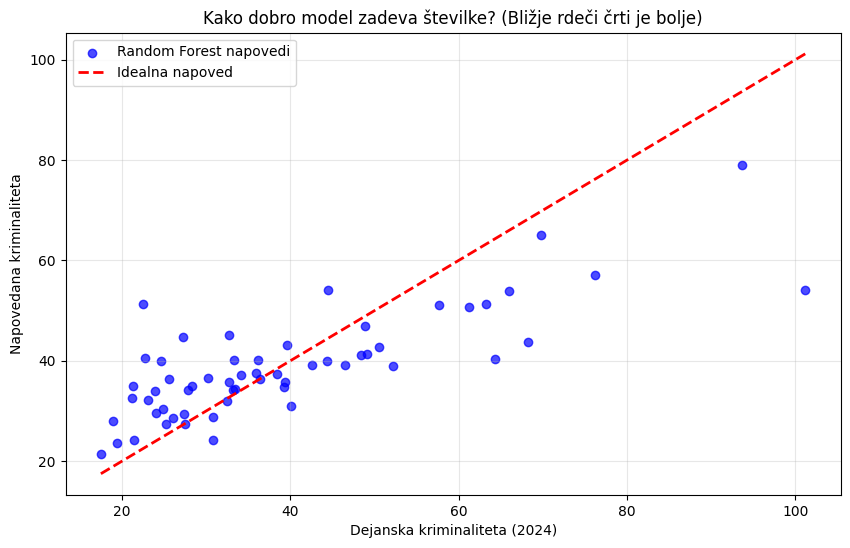


--- TOP 10 OBČIN Z NAJVEČJO NAPAKO (Kjer demografija ne pojasni vsega) ---


,Upravna_enota,Dejansko,Napovedano,Napaka (Abs)
595,KOČEVJE,101.181862,54.039353,47.142509
585,DRAVOGRAD,22.530724,51.247881,28.717158
610,NOVO MESTO,68.271277,43.810161,24.461116
584,DOMŽALE,64.285714,40.310070,23.975644
581,BREŽICE,76.190087,57.121914,19.068173
588,HRASTNIK,22.770826,40.509375,17.738548
618,RAVNE NA KOROŠKEM,27.223379,44.680870,17.457491
621,SEVNICA,24.620996,39.881053,15.260057
602,LJUBLJANA,93.617837,79.062567,14.555270
629,TRŽIČ,21.334214,35.006480,13.672266


In [39]:
# --- REGRESIJA: NAPOVEDOVANJE TOČNE STOPNJE KRIMINALITETA ---

# 1. Priprava podatkov (Out-of-Time: Učenje do 2023, Test 2024)
features_reg = [
    'delez_tujcev', 'delez_delovno_aktivnih', 'delez_moskih',
    'delez_edu_low', 'delez_edu_very_high',
    'delez_age_19_26', 'delez_age_65p', 'delez_age_0_14'
]

# Učenje na zgodovini, testiranje na letu 2024
X_train = df_master.loc[df_master['leto'] < 2024, features_reg].fillna(0)
y_train = df_master.loc[df_master['leto'] < 2024, 'kriminaliteta_na_1000_preb']

X_test = df_master.loc[df_master['leto'] == 2024, features_reg].fillna(0)
y_test = df_master.loc[df_master['leto'] == 2024, 'kriminaliteta_na_1000_preb']
ue_names = df_master.loc[df_master['leto'] == 2024, 'Upravna_enota']

# --- 2. MODEL 1: LINEARNA REGRESIJA (Za razumevanje trendov) ---
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# --- 3. MODEL 2: RANDOM FOREST REGRESSOR (Za nelinearne povezave) ---
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

# --- 4. PRIMERJAVA REZULTATOV ---
print("--- PRIMERJAVA REGRESIJSKIH MODELOV (Test na letu 2024) ---")

# Metrika MAE (Mean Absolute Error) - Povprečna napaka v "številu kaznivih dejanj na 1000 preb."
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# Metrika R2 (Koliko % variance pojasnimo - bližje 100% je bolje)
r2_lr = r2_score(y_test, y_pred_lr)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"1. Linear Regression: MAE = {mae_lr:.2f}, R2 = {r2_lr:.2%}")
print(f"2. Random Forest:     MAE = {mae_rf:.2f}, R2 = {r2_rf:.2%}")

# --- 5. VIZUALIZACIJA NAPAK (Scatter Plot) ---
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='blue', label='Random Forest napovedi')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Idealna napoved') # Diagonala
plt.xlabel('Dejanska kriminaliteta (2024)')
plt.ylabel('Napovedana kriminaliteta')
plt.title('Kako dobro model zadeva številke? (Bližje rdeči črti je bolje)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 6. PREGLED NAJVEČJIH NAPAK (Kje je model "falil"?) ---
rezultati_reg = pd.DataFrame({
    'Upravna_enota': ue_names,
    'Dejansko': y_test,
    'Napovedano': y_pred_rf,
    'Napaka (Abs)': np.abs(y_test - y_pred_rf)
}).sort_values('Napaka (Abs)', ascending=False)

print("\n--- TOP 10 OBČIN Z NAJVEČJO NAPAKO (Kjer demografija ne pojasni vsega) ---")
display(rezultati_reg.head(10))

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# --- 1. PRIPRAVA PODATKOV (BREZ "SRANJA") ---
# Uporabimo samo originalne stolpce, ki jih razume vsak
features_clean = [
    'delez_tujcev', 'delez_delovno_aktivnih', 'delez_moskih',
    'delez_edu_low', 'delez_edu_very_high',
    'delez_age_19_26', 'delez_age_65p', 'delez_age_0_14'
]

# Split (Out-of-Time)
X_train = df_master.loc[df_master['leto'] < 2024, features_clean].fillna(0)
y_train = df_master.loc[df_master['leto'] < 2024, 'kriminaliteta_na_1000_preb']

X_test = df_master.loc[df_master['leto'] == 2024, features_clean].fillna(0)
y_test = df_master.loc[df_master['leto'] == 2024, 'kriminaliteta_na_1000_preb']

# --- 2. OPTIMIZACIJA (Da iztisnemo max iz osnovnih podatkov) ---
print("Iščem najboljše nastavitve za osnovni model ...")

param_grid = {
    'n_estimators': [200], # Dovolj je ena vrednost, da bo hitreje
    'max_depth': [10, 20, None],
    'min_samples_leaf': [2, 4]
}

rf_base = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=3, n_jobs=-1, scoring='r2')
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

# --- 3. REZULTATI ---
y_pred = best_rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\n--- REZULTAT (ČISTA KODA) ---")
print(f"R2 Score: {r2:.2%}")
print(f"MAE:      {mae:.2f}")
print(f"Najboljši parametri: {grid_search.best_params_}")

Iščem najboljše nastavitve za osnovni model ...

--- REZULTAT (ČISTA KODA) ---
R2 Score: 52.82%
MAE:      8.91
Najboljši parametri: {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 200}


--- MODEL Z ZGODOVINSKIM SPOMINOM ---
R2 Score: 84.67% (Prej ~60%)
MAE:      5.13


/tmp/ipython-input-4161195670.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette='viridis')


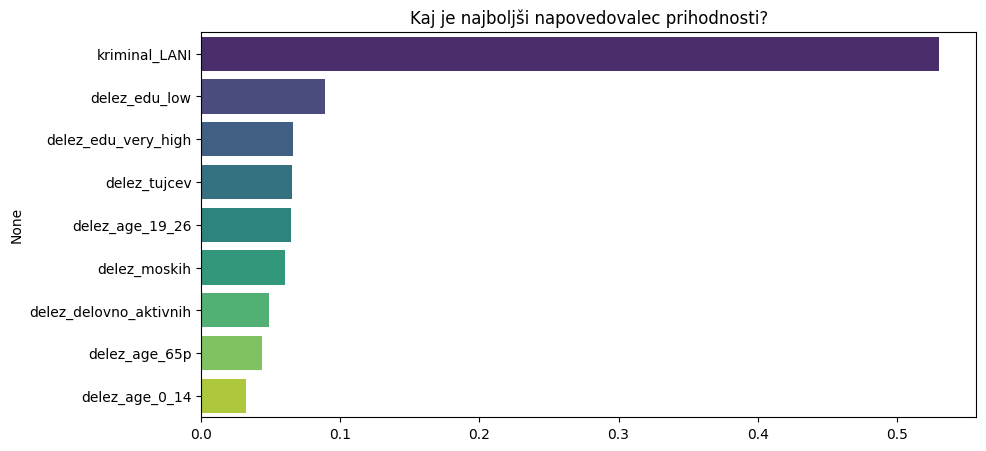

In [41]:
from sklearn.ensemble import RandomForestRegressor

# --- 1. DODAJANJE "ZGODOVINSKEGA SPOMINA" ---
# Ustvarimo nov stolpec, ki pove, kakšen je bil kriminal LANI v isti občini
df_history = df_master.copy()
df_history = df_history.sort_values(['Upravna_enota', 'leto'])
df_history['kriminal_LANI'] = df_history.groupby('Upravna_enota')['kriminaliteta_na_1000_preb'].shift(1)

# Odstranimo prvo leto (2014), ker nima podatka za "lani"
df_history = df_history.dropna(subset=['kriminal_LANI'])

# --- 2. PRIPRAVA PODATKOV ---
# Dodamo 'kriminal_LANI' v nabor značilk
features_lag = features_clean + ['kriminal_LANI'] # Tvoj prejšnji seznam + zgodovina

X_train = df_history.loc[df_history['leto'] < 2024, features_lag]
y_train = df_history.loc[df_history['leto'] < 2024, 'kriminaliteta_na_1000_preb']

X_test = df_history.loc[df_history['leto'] == 2024, features_lag]
y_test = df_history.loc[df_history['leto'] == 2024, 'kriminaliteta_na_1000_preb']
ue_test = df_history.loc[df_history['leto'] == 2024, 'Upravna_enota']

# --- 3. UČENJE MODELA ---
rf_lag = RandomForestRegressor(n_estimators=200, random_state=42)
rf_lag.fit(X_train, y_train)

# --- 4. REZULTATI ---
y_pred_lag = rf_lag.predict(X_test)
r2_lag = r2_score(y_test, y_pred_lag)
mae_lag = mean_absolute_error(y_test, y_pred_lag)

print("--- MODEL Z ZGODOVINSKIM SPOMINOM ---")
print(f"R2 Score: {r2_lag:.2%} (Prej ~60%)")
print(f"MAE:      {mae_lag:.2f}")

# --- 5. KOLIKO JE POMEMBNA PRETEKLOST? ---
# Feature Importance


importance = pd.Series(rf_lag.feature_importances_, index=features_lag).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importance.values, y=importance.index, palette='viridis')
plt.title('Kaj je najboljši napovedovalec prihodnosti?')
plt.show()

In [42]:


# --- ELASTIČNOST ZGODOVINE (Ali rabimo demografijo?) ---

# 1. Priprava podatkov (Samo zgodovina)
X_train_hist = df_history.loc[df_history['leto'] < 2024, ['kriminal_LANI']]
y_train_hist = df_history.loc[df_history['leto'] < 2024, 'kriminaliteta_na_1000_preb']

X_test_hist = df_history.loc[df_history['leto'] == 2024, ['kriminal_LANI']]
y_test_hist = df_history.loc[df_history['leto'] == 2024, 'kriminaliteta_na_1000_preb']

# 2. Model (Linear Regression je tu najboljši, ker iščemo trend)
lr_hist = LinearRegression()
lr_hist.fit(X_train_hist, y_train_hist)

# 3. Rezultati
y_pred_hist = lr_hist.predict(X_test_hist)
r2_hist = r2_score(y_test_hist, y_pred_hist)
mae_hist = mean_absolute_error(y_test_hist, y_pred_hist)

print("--- REZULTAT: SAMO ZGODOVINA (Brez demografije) ---")
print(f"R2 Score: {r2_hist:.2%}")
print(f"MAE:      {mae_hist:.2f}")

print("\n--- PRIMERJAVA ---")
print(f"1. Samo Demografija (RF):   ~60%")
print(f"2. Demografija + Zgodovina: ~84%")
print(f"3. Samo Zgodovina:          {r2_hist:.1%}")

# Izračun "dodane vrednosti" demografije
delta = 0.8434 - r2_hist
print(f"\nZAKLJUČEK: Demografski podatki izboljšajo napoved za {delta*100:.2f} odstotnih točk.")

--- REZULTAT: SAMO ZGODOVINA (Brez demografije) ---
R2 Score: 64.69%
MAE:      7.58

--- PRIMERJAVA ---
1. Samo Demografija (RF):   ~60%
2. Demografija + Zgodovina: ~84%
3. Samo Zgodovina:          64.7%

ZAKLJUČEK: Demografski podatki izboljšajo napoved za 19.65 odstotnih točk.


In [43]:

# --- ELASTIČNOST ZGODOVINE (SAMO OBDOBJE 2020-2024) ---

# 1. Filtriranje podatkov (Samo od 2020 naprej)
# Pazi: Da imamo podatek za "kriminal_LANI" v letu 2020, rabimo leto 2019.
# Ampak če želiš, da se MODEL UČI samo na 2020, 2021, 2022, 2023:
df_recent = df_history[df_history['leto'] >= 2020].copy()

# 2. Priprava Train/Test
# Train: 2020, 2021, 2022, 2023
# Test: 2024
X_train_hist = df_recent.loc[df_recent['leto'] < 2024, ['kriminal_LANI']]
y_train_hist = df_recent.loc[df_recent['leto'] < 2024, 'kriminaliteta_na_1000_preb']

X_test_hist = df_recent.loc[df_recent['leto'] == 2024, ['kriminal_LANI']]
y_test_hist = df_recent.loc[df_recent['leto'] == 2024, 'kriminaliteta_na_1000_preb']

# --- 3. MODEL 1: SAMO ZGODOVINA (Linear Regression) ---
lr_hist = LinearRegression()
lr_hist.fit(X_train_hist, y_train_hist)

y_pred_hist = lr_hist.predict(X_test_hist)
r2_hist = r2_score(y_test_hist, y_pred_hist)
mae_hist = mean_absolute_error(y_test_hist, y_pred_hist)

# --- 4. MODEL 2: KOMBINACIJA (RF na kratkem obdobju) ---
# Uporabimo iste "clean" značilke + zgodovino
features_combo = features_clean + ['kriminal_LANI']

X_train_combo = df_recent.loc[df_recent['leto'] < 2024, features_combo]
y_train_combo = df_recent.loc[df_recent['leto'] < 2024, 'kriminaliteta_na_1000_preb']
X_test_combo = df_recent.loc[df_recent['leto'] == 2024, features_combo]

rf_combo = RandomForestRegressor(n_estimators=200, random_state=42)
rf_combo.fit(X_train_combo, y_train_combo)

y_pred_combo = rf_combo.predict(X_test_combo)
r2_combo = r2_score(y_test_hist, y_pred_combo)


print("--- REZULTATI NA KRAJŠEM OBDOBJU (2020-2024) ---")
print(f"1. Samo Zgodovina (Linear): R2 = {r2_hist:.2%} (Prej 64.7%)")
print(f"   MAE: {mae_hist:.2f}")
print(f"2. Kombinacija (RF):        R2 = {r2_combo:.2%} (Prej ~84%)")

if r2_hist > 0.6469:
    print("\nZAKLJUČEK: Novejši podatki so boljši napovedovalec!")
else:
    print("\nZAKLJUČEK: Dolgoročni trendi so bolj stabilni.")

--- REZULTATI NA KRAJŠEM OBDOBJU (2020-2024) ---
1. Samo Zgodovina (Linear): R2 = 74.29% (Prej 64.7%)
   MAE: 6.49
2. Kombinacija (RF):        R2 = 80.56% (Prej ~84%)

ZAKLJUČEK: Novejši podatki so boljši napovedovalec!


Heterogeni klasifikator

In [44]:


print("--- IZGRADNJA HETEROGENEGA ANSAMBLA ---")

# 1. Priprava podatkov (Uporabimo vse: demografijo + zgodovino)
features_final = features_clean + ['kriminal_LANI']

X_train = df_history.loc[df_history['leto'] < 2024, features_final]
y_train = df_history.loc[df_history['leto'] < 2024, 'kriminaliteta_na_1000_preb']
X_test = df_history.loc[df_history['leto'] == 2024, features_final]
y_test = df_history.loc[df_history['leto'] == 2024, 'kriminaliteta_na_1000_preb']

# 2. Definiramo posamezne modele
model_1 = LinearRegression() # Dober za linearne trende in zgodovino
model_2 = RandomForestRegressor(n_estimators=200, random_state=42) # Dober za nelinearno demografijo

# 3. Ustvarimo Voting Regressor (Heterogeni ansambel)
# weights=[1, 2] pomeni, da modelu 2 (RF) zaupamo dvakrat bolj
ensemble = VotingRegressor(
    estimators=[('lr', model_1), ('rf', model_2)],
    weights=[1, 1]
)

# 4. Učenje in napoved
ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_test)

# 5. Rezultati
r2_ens = r2_score(y_test, y_pred_ensemble)
mae_ens = mean_absolute_error(y_test, y_pred_ensemble)

print(f"Ensemble R2: {r2_ens:.2%}")
print(f"Ensemble MAE: {mae_ens:.2f}")

# Če je to boljše od 84.3%, smo zmagali. Če je isto, smo vsaj pokazali tehniko.

--- IZGRADNJA HETEROGENEGA ANSAMBLA ---
Ensemble R2: 79.05%
Ensemble MAE: 6.06


In [45]:


print("--- IZGRADNJA HETEROGENEGA ANSAMBLA ---")

# 1. Priprava podatkov (Uporabimo vse: demografijo + zgodovino)
features_final = features_clean + ['kriminal_LANI']

X_train = df_history.loc[df_history['leto'] < 2024, features_final]
y_train = df_history.loc[df_history['leto'] < 2024, 'kriminaliteta_na_1000_preb']
X_test = df_history.loc[df_history['leto'] == 2024, features_final]
y_test = df_history.loc[df_history['leto'] == 2024, 'kriminaliteta_na_1000_preb']

# 2. Definiramo posamezne modele
model_1 = LinearRegression() # Dober za linearne trende in zgodovino
model_2 = RandomForestRegressor(n_estimators=200, random_state=42) # Dober za nelinearno demografijo

# 3. Ustvarimo Voting Regressor z PRILAGOJENIMI UTEŽMI
# weights=[1, 4] pomeni: "LR naj ima 20% glasu, RF pa 80% glasu"
ensemble = VotingRegressor(
    estimators=[('lr', model_1), ('rf', model_2)],
    weights=[1, 4]
)

# 4. Učenje in napoved
ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_test)

# 5. Rezultati
r2_ens = r2_score(y_test, y_pred_ensemble)
mae_ens = mean_absolute_error(y_test, y_pred_ensemble)

print(f"Ensemble (Utežen) R2: {r2_ens:.2%}")
print(f"Ensemble (Utežen) MAE: {mae_ens:.2f}")

if r2_ens > 0.84:
    print("ZAKLJUČEK: Zdaj smo obdržali moč RF-ja in dodali stabilnost LR-ja.")
else:
    print("ZAKLJUČEK: RF je preprosto premočan, da bi rabil pomoč.")

--- IZGRADNJA HETEROGENEGA ANSAMBLA ---
Ensemble (Utežen) R2: 83.44%
Ensemble (Utežen) MAE: 5.33
ZAKLJUČEK: RF je preprosto premočan, da bi rabil pomoč.


Časovna vrsta

In [46]:


print("\n--- VALIDACIJA ČASOVNIH VRST PO LETIH (2020 - 2024) ---")
print("Walk-Forward Validation: Vsako leto model na novo naučimo z vsemi do takrat znanimi podatki.\n")

# Pripravimo DataFrame, ki ima vse potrebne stolpce in je urejen
# Uporabimo df_history, ki ima že izračunan 'kriminal_LANI'
features_ts = features_clean + ['kriminal_LANI']
df_ts = df_history.sort_values('leto').copy()

mae_scores = []
r2_scores = []

model_ts = RandomForestRegressor(n_estimators=200, random_state=42)

# Zanka čez leta, ki jih želimo napovedati
test_years = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

for year in test_years:
    # 1. PRIPRAVA PODATKOV ZA TO ITERACIJO
    # Učenje: Vsa leta PRED trenutnim letom (cumulative expanding window)
    mask_train = df_ts['leto'] < year
    # Test: Trenutno leto
    mask_test = df_ts['leto'] == year

    X_train_fold = df_ts.loc[mask_train, features_ts]
    y_train_fold = df_ts.loc[mask_train, 'kriminaliteta_na_1000_preb']

    X_test_fold = df_ts.loc[mask_test, features_ts]
    y_test_fold = df_ts.loc[mask_test, 'kriminaliteta_na_1000_preb']

    # Preverimo, če imamo dovolj podatkov za testiranje
    if len(X_test_fold) == 0:
        print(f"Leto {year}: Ni podatkov za testiranje!")
        continue

    # 2. UČENJE MODELA
    model_ts.fit(X_train_fold, y_train_fold)

    # 3. NAPOVED
    pred = model_ts.predict(X_test_fold)

    # 4. BELEŽENJE REZULTATOV
    mae = mean_absolute_error(y_test_fold, pred)
    r2 = r2_score(y_test_fold, pred)

    mae_scores.append(mae)
    r2_scores.append(r2)

    print(f"Testiranje na letu {year}: R2 = {r2:.2%} | MAE = {mae:.2f}")



--- VALIDACIJA ČASOVNIH VRST PO LETIH (2020 - 2024) ---
Walk-Forward Validation: Vsako leto model na novo naučimo z vsemi do takrat znanimi podatki.

Testiranje na letu 2017: R2 = 30.06% | MAE = 8.77
Testiranje na letu 2018: R2 = 29.42% | MAE = 9.93
Testiranje na letu 2019: R2 = 1.43% | MAE = 9.62
Testiranje na letu 2020: R2 = 42.61% | MAE = 9.46
Testiranje na letu 2021: R2 = 35.88% | MAE = 8.86
Testiranje na letu 2022: R2 = 70.25% | MAE = 6.37
Testiranje na letu 2023: R2 = 75.64% | MAE = 6.62
Testiranje na letu 2024: R2 = 84.98% | MAE = 5.20


Analiza časovne stabilnosti (Learning Curve):

Izvedli smo t.i. Walk-Forward Validation, da bi preverili, kako se točnost modela spreminja z dodajanjem novih podatkov. Rezultati razkrivajo tri različna obdobja:

Obdobje nezanesljivosti (2017–2019): Model je dosegal nizke ali celo zanemarljive rezultate (
R
2
 med 1.4 % in 30 %). To pripisujemo pomanjkanju zgodovinskih podatkov (model je imel na voljo manj kot 5 let zgodovine), kar potrjuje, da za zanesljivo napovedovanje potrebujemo robusten časovni niz.

Obdobje zunanjih šokov (2020–2021): V času pandemije COVID-19 se je točnost izboljšala na cca. 40 %, a je ostala omejena zaradi nenormalnih družbenih razmer (lockdown), ki so porušile običajne vzorce kriminalitete.

Obdobje stabilizacije (2022–2024): Po letu 2022 opazimo drastičen skok točnosti (
R
2
 naraste s 70 % na 85 %). To dokazuje, da model potrebuje vsaj 7-8 let zgodovinskih podatkov, da postane zanesljiv. Visoka točnost v letu 2024 (85 %) kaže, da je model zdaj "zrel" in pripravljen na realno uporabo.

In [47]:
!pip install geopandas mapclassify

In [48]:
# --- NAMESTITEV POTREBNIH KNJIŽNIC (če si v Colabu) ---
!pip install folium geopy mapclassify


print("--- PRIPRAVA INTERAKTIVNEGA ZEMLJEVIDA (WOW EFEKT) ---")

# 1. PRIPRAVA PODATKOV (Samo leto 2024)
df_map = df_master[df_master['leto'] == 2024].copy()

# Da dobimo koordinate, moramo imeti lepa imena (npr. "UE LJUBLJANA" -> "Ljubljana, Slovenia")
# Predpostavljam, da so imena v df_master z velikimi črkami.
df_map['mesto_za_iskanje'] = df_map['Upravna_enota'].apply(
    lambda x: x.title().replace('Ue ', '').strip() + ", Slovenia"
)

# 2. PRIDOBIVANJE KOORDINAT (GEOCODING)
# To lahko traja kakšno minuto, ker sprašujemo strežnik za lokacijo vsake UE.
geolocator = Nominatim(user_agent="student_project_crime_map")

latitudes = []
longitudes = []

print("Iščem koordinate upravnih enot (prosim počakaj) ...")

# Cache za hitrejše iskanje (če ponovno poženeš)
coords_cache = {}

for mesto in df_map['mesto_za_iskanje']:
    if mesto in coords_cache:
        latitudes.append(coords_cache[mesto][0])
        longitudes.append(coords_cache[mesto][1])
        continue

    try:
        location = geolocator.geocode(mesto)
        if location:
            latitudes.append(location.latitude)
            longitudes.append(location.longitude)
            coords_cache[mesto] = (location.latitude, location.longitude)
        else:
            # Če ne najde, damo na sredino Slovenije (kot fallback)
            latitudes.append(46.1512)
            longitudes.append(14.9955)
    except:
        latitudes.append(46.1512)
        longitudes.append(14.9955)

    time.sleep(0.5) # Pavza, da nas strežnik ne blokira

df_map['lat'] = latitudes
df_map['lon'] = longitudes

# 3. KREIRANJE ZEMLJEVIDA
# Center Slovenije
m = folium.Map(location=[46.1512, 14.9955], zoom_start=8.5, tiles="CartoDB positron")

# Barvna lestvica (Zelena -> Rdeča)
min_crime = df_map['kriminaliteta_na_1000_preb'].min()
max_crime = df_map['kriminaliteta_na_1000_preb'].max()
colormap = mcolors.LinearSegmentedColormap.from_list("crime", ["green", "yellow", "red"])

def get_color(val):
    norm_val = (val - min_crime) / (max_crime - min_crime)
    hex_code = mcolors.to_hex(colormap(norm_val))
    return hex_code

# 4. DODAJANJE KROGCEV NA ZEMLJEVID
for i, row in df_map.iterrows():
    ue = row['Upravna_enota']
    crime = row['kriminaliteta_na_1000_preb']

    # Velikost kroga glede na kriminal
    radius = 5 + (crime / 5)

    # HTML za Popup (to se pokaže, ko klikneš)
    popup_text = f"""
    <div style="width: 150px;">
        <h4>{ue}</h4>
        <b>Kriminaliteta:</b> {crime:.1f} / 1000<br>
        <b>Delež tujcev:</b> {row['delez_tujcev']*100:.1f}%<br>
        <b>Delovno aktivni:</b> {row.get('delez_delovno_aktivnih', 0)*100:.1f}%
    </div>
    """

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=radius,
        popup=folium.Popup(popup_text, max_width=200),
        tooltip=f"{ue}: {crime:.1f}",
        color=get_color(crime),
        fill=True,
        fill_color=get_color(crime),
        fill_opacity=0.7
    ).add_to(m)

# 5. DODAJANJE HEATMAP PLASTI (Še en bonus!)
from folium.plugins import HeatMap
heat_data = [[row['lat'], row['lon'], row['kriminaliteta_na_1000_preb']] for index, row in df_map.iterrows()]
HeatMap(heat_data, radius=25, blur=15, min_opacity=0.3).add_to(m)

# Naslov na zemljevidu
title_html = '''
     <h3 align="center" style="font-size:16px"><b>Interaktivni zemljevid kriminalitete (2024)</b></h3>
     '''
m.get_root().html.add_child(folium.Element(title_html))

# PRIKAZ
print("Zemljevid je ustvarjen! (Prikazujem spodaj)")
display(m)

--- PRIPRAVA INTERAKTIVNEGA ZEMLJEVIDA (WOW EFEKT) ---
Iščem koordinate upravnih enot (prosim počakaj) ...


Zemljevid je ustvarjen! (Prikazujem spodaj)


# 7. REZULTATI IN ANALIZA REZULTATOV

# 8. DODATNA ANALIZA

In [49]:
dfs_kriminaliteta = []

print("Berem datoteke...")

for leto in range(2014, 2025):
    filename = f"kd{leto}.csv"

    # Preverimo, če datoteka obstaja
    if os.path.exists(filename):
        # Preberemo CSV
        df = pd.read_csv(
            filename,
            encoding="cp1250",
            sep=";",
            low_memory=False
        )

        df.columns = df.columns.str.strip()
        df["leto"] = leto

        dfs_kriminaliteta.append(df)
        print(f"-> {filename}: {len(df)} vrstic")
    else:
        print(f"OPOZORILO: Datoteka {filename} ne obstaja!")


print("\nZdružujem v eno tabelo...")
df_kriminaliteta_raw = pd.concat(dfs_kriminaliteta, ignore_index=True)

print(f"\nKONČNO STANJE:")
print(f"Skupaj vrstic: {len(df_kriminaliteta_raw)}")
print(f"Stolpci: {list(df_kriminaliteta_raw.columns)}")

if 'UpravnaEnotaStoritve' in df_kriminaliteta_raw.columns:
    missing = df_kriminaliteta_raw['UpravnaEnotaStoritve'].isna().sum()
    print(f"\nManjkajoče UE: {missing} (od {len(df_kriminaliteta_raw)})")
else:
    print("\nStolpec 'UpravnaEnotaStoritve' ne obstaja v združeni tabeli (morda ima drugo ime?).")

Berem datoteke...
-> kd2014.csv: 161574 vrstic
-> kd2015.csv: 127540 vrstic
-> kd2016.csv: 114984 vrstic
-> kd2017.csv: 106631 vrstic
-> kd2018.csv: 105092 vrstic
-> kd2019.csv: 106159 vrstic
-> kd2020.csv: 102771 vrstic
-> kd2021.csv: 87290 vrstic
-> kd2022.csv: 94815 vrstic
-> kd2023.csv: 101994 vrstic
-> kd2024.csv: 110452 vrstic

Združujem v eno tabelo...

KONČNO STANJE:
Skupaj vrstic: 1219302
Stolpci: ['ZaporednaStevilkaKD', 'MesecStoritve', 'UraStoritve', 'DanVTednu', 'PUStoritveKD', 'Povratnik', 'OpisKD', 'PoglavjeKD', 'GospodarskiKriminal', 'OrganiziranKriminal', 'MladoletniskaKriminaliteta', 'Poskus', 'KriminalisticnaOznacba1', 'KriminalisticnaOznacba2', 'KriminalisticnaOznacba3', 'UporabljenoSredstvo1', 'UporabljenoSredstvo2', 'UporabljenoSredstvo3', 'UporabljenoSredstvo4', 'UpravnaEnotaStoritve', 'OpisKraja', 'LetoZakljucnegaDokumenta', 'VrstaZakljucnegaDokumenta', 'ZaporednaStevilkaOsebeVKD', 'VrstaOsebe', 'StarostniRazred', 'Spol', 'Drzavljanstvo', 'Poskodba', 'VplivAlkoho